# Holten 2010 multi-tracer benchmark

This notebook accompanies the Holten example implemented in `examples/natural/holten/`.

Visser et al. (2013) studied groundwater age distributions in a public drinking-water well field near Holten, in the Netherlands, using several transient tracers. The scientific problem is practical and hydrogeologically important: long-screened production wells mix waters of different ages, so the goal is not to assign one apparent age to each well, but to understand the age mixture that controls present-day well vulnerability.

The paper shows in particular that a discrete `4-bin` model and a dispersion model with an old-water fraction both reproduce the observations reasonably well. It also highlights a strong contrast between shallower wells dominated by water younger than about `20` years and deeper wells containing a substantial fraction older than `60` years.

This notebook is intentionally didactic:
- it separates what comes directly from the paper from what is adapted for PyAge;
- it explains the tracer preparation choices before any inversion;
- it shows where the sampled values sit relative to physically meaningful reference curves;
- it runs the local article-style `4-bin` helper already implemented in this example;
- and it compares the paper's `4-bin` fractions with the posterior distributions obtained from a local Metropolis-Hastings calibration of that same Holten-specific `4-bin` helper.


In [1]:
from pathlib import Path
import sys
import importlib

from IPython.display import Image, display

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "pyage").exists():
        repo_root = candidate
        break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

holten_case_module = importlib.import_module("examples.natural.holten.holten_case")
holten_prepare_module = importlib.import_module("examples.natural.holten.holten_prepare")
holten_benchmark_module = importlib.import_module("examples.natural.holten.holten_benchmark")
holten_four_bin_module = importlib.import_module("examples.natural.holten.holten_four_bin")

holten_case_module = importlib.reload(holten_case_module)
holten_prepare_module = importlib.reload(holten_prepare_module)
holten_benchmark_module = importlib.reload(holten_benchmark_module)
holten_four_bin_module = importlib.reload(holten_four_bin_module)

build_context = holten_case_module.build_context
prepare_holten_inputs = holten_prepare_module.prepare_holten_inputs
build_article_reference_figures = holten_benchmark_module.build_article_reference_figures
build_pre_model_figures = holten_benchmark_module.build_pre_model_figures
run_local_4bin = holten_four_bin_module.run_local_4bin
run_local_4bin_mh = holten_four_bin_module.run_local_4bin_mh

ctx = build_context()
prepared = prepare_holten_inputs()
ctx

HoltenContext(paths=HoltenPaths(repo_root=WindowsPath('C:/codes/pyage'), example_dir=WindowsPath('C:/codes/pyage/examples/natural/holten'), data_dir=WindowsPath('C:/codes/pyage/examples/natural/holten/data'), doc_dir=WindowsPath('C:/codes/pyage/examples/natural/holten/doc'), generated_dir=WindowsPath('C:/codes/pyage/examples/natural/holten/generated'), launcher_config_dir=WindowsPath('C:/codes/pyage/examples/natural/holten/generated/launcher_configs'), tracer_source_dir=WindowsPath('C:/codes/pyage/examples/natural/holten/tracers'), prepared_tracer_dir=WindowsPath('C:/codes/pyage/examples/natural/holten/prepared_tracers/data_tracer'), lpm_data_dir=WindowsPath('C:/codes/pyage/examples/natural/holten/data_lpm'), yaml_path=WindowsPath('C:/codes/pyage/examples/natural/holten/holten.yaml'), sampling_raw_path=WindowsPath('C:/codes/pyage/examples/natural/holten/doc/sampling_data.txt'), tritium_raw_path=WindowsPath('C:/codes/pyage/examples/natural/holten/doc/local_tritium.txt'), kr85_raw_path=W

## 1. What comes directly from the paper

The following points are taken directly from the paper and from the local Holten source files:
- the case study concerns production wells sampled in April 2010 within the Holten well field;
- the core question is the age distribution of pumped water, not a single apparent age per well;
- the paper mainly relies on `3H/3He`, `85Kr`, and `39Ar`, with `4He` helping to diagnose the older component;
- short-screen monitoring wells around the well field are used to constrain vertical age stratification in the aquifer;
- the paper compares several model families, including discrete binned models and continuous distribution models with an old-water fraction;
- and it clearly separates younger, more vulnerable wells from deeper wells with a stronger old-water contribution.

In this repository, the V1 implementation draws its input data explicitly from:
- `sampling_data.txt` for production-well observations;
- `local_tritium.txt` for the `3H` input history;
- `freiburg_krypton.txt` for the `kr85` input history;
- `calibration_results.txt` and `visser_data.xlsx` for the published benchmark values.

The notebook now keeps the seven published production wells that have the Holten benchmark trio `3H`, `kr85`, and `39Ar`: `59-05`, `67-19`, `72-22`, `73-29`, `85-33`, `85-34`, and `85-35`. For the added local `3H/3He` branch, `59-05` uses a documented local fallback `3He_err = 0.5 TU`, equal to the median reported `3He_err` across the selected wells, because the source table leaves that uncertainty blank.


In [2]:
prepared.observed_aggregated


,well_id,element,concentration,error,unit,date
0,59-05,3H,6.48,0.14,TU,2010.29863
1,59-05,kr85,38.00,1.20,dpm/ccKr,2010.29863
2,59-05,39Ar,1.00,0.10,%modern,2010.29863
3,67-19,3H,6.09,0.15,TU,2010.30137
4,67-19,kr85,39.70,1.50,dpm/ccKr,2010.30137
5,67-19,39Ar,1.04,0.08,%modern,2010.30137
6,72-22,3H,6.75,0.16,TU,2010.29863
7,72-22,kr85,35.90,1.30,dpm/ccKr,2010.29863
8,72-22,39Ar,0.93,0.06,%modern,2010.29863
9,73-29,3H,6.38,0.16,TU,2010.29863


## 2. What is adapted for PyAge and why

The goal is not to dilute Holten into the repository's generic tracer conventions, but to stay as close as possible to the paper while keeping the example executable today. The main adaptations are therefore explicit:
- `kr85` is kept in `dpm/ccKr` rather than converted to `pptv`, because this is the unit most directly connected to the Holten observations;
- `39Ar` is converted from `pMC` to a numerical fraction of modern, which matches the current internal PyAge convention;
- Holten tracers are prepared locally under `prepared_tracers/data_tracer/`, with no fallback to generic tracer definitions from the repository;
- a local article-style `4-bin` helper is implemented for this example, because the tracer-specific `old` end-member should not yet be forced into the generic PyAge LPM stack;
- and the local Metropolis-Hastings comparison shown later is run on this Holten-specific `4-bin` helper, not on the temporary bootstrap `uniform` launcher model.
- `3H/3He` and `He4_terr` are now prepared as a Holten-specific helium layer: they are exported and visualized, and `3He_trit` now also enters the local Holten `4-bin` helper without being pushed into the generic PyAge calibration stack.
- for `59-05`, the local Holten workflow fills missing `3He_err` with the median reported `3He_err` of the selected wells (`0.5 TU`) so the local article-style `4-bin` helper can run on the full published production-well set.

This distinction matters: a comparison of `chi2` values or of `uniform` parameters would not answer the scientific question asked in the paper. The meaningful comparison is between the paper's `4-bin` fractions and the posterior distribution of the same fractions in a Holten-specific `4-bin` calibration.


In [3]:
prepared.preparation_log


,well_id,element,raw_value,raw_unit,converted_value,converted_unit,conversion_rule,source_field
0,59-05,3H,6.48,TU,6.48,TU,none,3H_TU
1,59-05,kr85,38.00,dpm/ccKr,38.00,dpm/ccKr,none,Kr85_dpm_ccKr
2,59-05,39Ar,100.00,pMC,1.00,%modern,pMC / 100,Ar39_pMC
3,67-19,3H,6.09,TU,6.09,TU,none,3H_TU
4,67-19,kr85,39.70,dpm/ccKr,39.70,dpm/ccKr,none,Kr85_dpm_ccKr
5,67-19,39Ar,104.00,pMC,1.04,%modern,pMC / 100,Ar39_pMC
6,72-22,3H,6.75,TU,6.75,TU,none,3H_TU
7,72-22,kr85,35.90,dpm/ccKr,35.90,dpm/ccKr,none,Kr85_dpm_ccKr
8,72-22,39Ar,93.00,pMC,0.93,%modern,pMC / 100,Ar39_pMC
9,73-29,3H,6.38,TU,6.38,TU,none,3H_TU


### Diagnostic helium layer

The calibration dataset still contains only `3H`, `kr85`, and `39Ar`. In parallel, the preparation step now exports a diagnostic Holten-specific helium table. It keeps together:
- `3H` and `3He_trit` as the coupled `3H/3He` branch;
- `3H + 3He_trit` as a reconstructed initial tritium indicator;
- the reported `3H/3He` apparent age and a ratio-based reconstruction from the prepared values;
- `He4_terr`, `He4`, and `DeltaNe_pct` as interpretation context rather than calibration targets.

This is the bridge between the paper's helium reasoning and the current executable PyAge workflow. The table also makes the `3He_err` fallback explicit when the source file leaves that field blank.

In [4]:
if not hasattr(prepared, "helium_diagnostics"):
    import importlib
    import examples.natural.holten.holten_prepare as holten_prepare_module

    holten_prepare_module = importlib.reload(holten_prepare_module)
    prepare_holten_inputs = holten_prepare_module.prepare_holten_inputs
    prepared = prepare_holten_inputs()

prepared.helium_diagnostics.round(3)

,well_id,date,3H_TU,3H_err,3He_trit_TU,3He_err_raw,3He_err,3He_err_source,tritium_initial_TU,tritium_initial_err,H3_He_age_yr,H3_He_age_err,H3_He_age_ratio_yr,H3_He_age_ratio_delta_yr,He4_terr,He4_total,DeltaNe_pct,DeltaNe_screening
0,59-05,2010.299,6.48,0.14,21.1,NaN,0.5,median_fallback_selected_wells,27.58,0.519,25.7,NaN,25.743,0.043,0.0,NaN,-7.0,limited_air_effects
1,67-19,2010.301,6.09,0.15,6.4,0.5,0.5,reported,12.49,0.522,12.7,0.8,12.767,0.067,0.1,0.33,26.0,strong_air_effects
2,72-22,2010.299,6.75,0.16,14.0,0.5,0.5,reported,20.75,0.525,20.0,0.5,19.960,-0.040,0.0,0.34,20.0,moderate_air_effects
3,73-29,2010.299,6.38,0.16,8.7,0.5,0.5,reported,15.08,0.525,15.3,0.7,15.289,-0.011,0.0,0.34,13.0,moderate_air_effects
4,85-33,2010.299,1.23,0.05,9.2,0.5,0.5,reported,10.43,0.502,38.0,1.1,37.995,-0.005,11.0,0.35,17.0,moderate_air_effects
5,85-34,2010.301,3.98,0.11,21.1,0.5,0.5,reported,25.08,0.512,32.7,0.6,32.718,0.018,6.6,0.36,6.0,limited_air_effects
6,85-35,2010.301,3.82,0.11,20.4,0.5,0.5,reported,24.22,0.512,32.8,0.6,32.827,0.027,4.5,0.36,16.0,moderate_air_effects


## 3. Reference curves and pre-model reading

These figures are designed as a didactic step before calibration. They do not yet show a fitted age distribution. Instead, they answer a simpler question: *if we take each tracer seriously on its own, where do the 2010 sampled values sit relative to a physically meaningful reference curve?*

Each tracer figure has two complementary panels:
- the **top panel** shows a reference curve together with the 2010 sampled values;
- the **bottom panel** summarizes the concentration range of that same reference curve and places the sampled values inside that range.

The top panel should be read differently for the three tracers:
- for `3H`, the blue curve is the local tritium input history after radioactive decay has been applied up to the 2010 sampling year;
- for `kr85`, the blue curve is the local krypton-85 input history, converted to Holten units and then decayed to the 2010 sampling year;
- for `39Ar`, the blue curve is a theoretical decay curve referenced to the same 2010 sampling year, because the atmospheric modern reference is treated as constant in V1.

These are still pre-model figures. They build intuition, but they do not replace the age-distribution model itself.


In [5]:
if not hasattr(prepared, "helium_diagnostics"):
    import importlib
    import examples.natural.holten.holten_prepare as holten_prepare_module
    import examples.natural.holten.holten_benchmark as holten_benchmark_module

    holten_prepare_module = importlib.reload(holten_prepare_module)
    holten_benchmark_module = importlib.reload(holten_benchmark_module)
    prepare_holten_inputs = holten_prepare_module.prepare_holten_inputs
    build_pre_model_figures = holten_benchmark_module.build_pre_model_figures
    prepared = prepare_holten_inputs()

pre_model_dir = ctx.paths.benchmark_dir / "pre_model"
generated = build_pre_model_figures(prepared, pre_model_dir)
generated

[WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/tracer_3H_history_and_observations.png'),
 WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/tracer_3H_value_range_position.png'),
 WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/tracer_kr85_history_and_observations.png'),
 WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/tracer_kr85_value_range_position.png'),
 WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/tracer_39Ar_history_and_observations.png'),
 WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/tracer_39Ar_value_range_position.png'),
 WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/well_59-05_multi_tracer_panel.png'),
 WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/pre_model/well_67-19_multi_tracer_panel.png'),
 WindowsPath('

### Tracer-by-tracer view

Read these figures in this order:
- compare each red point with the blue reference curve in the top panel;
- then use the lower panel to see whether each sampled value lies in the low, central, or high part of that tracer's reference range;
- finally, compare the three tracers together: the useful signal does not come from one tracer alone, but from their combined consistency.


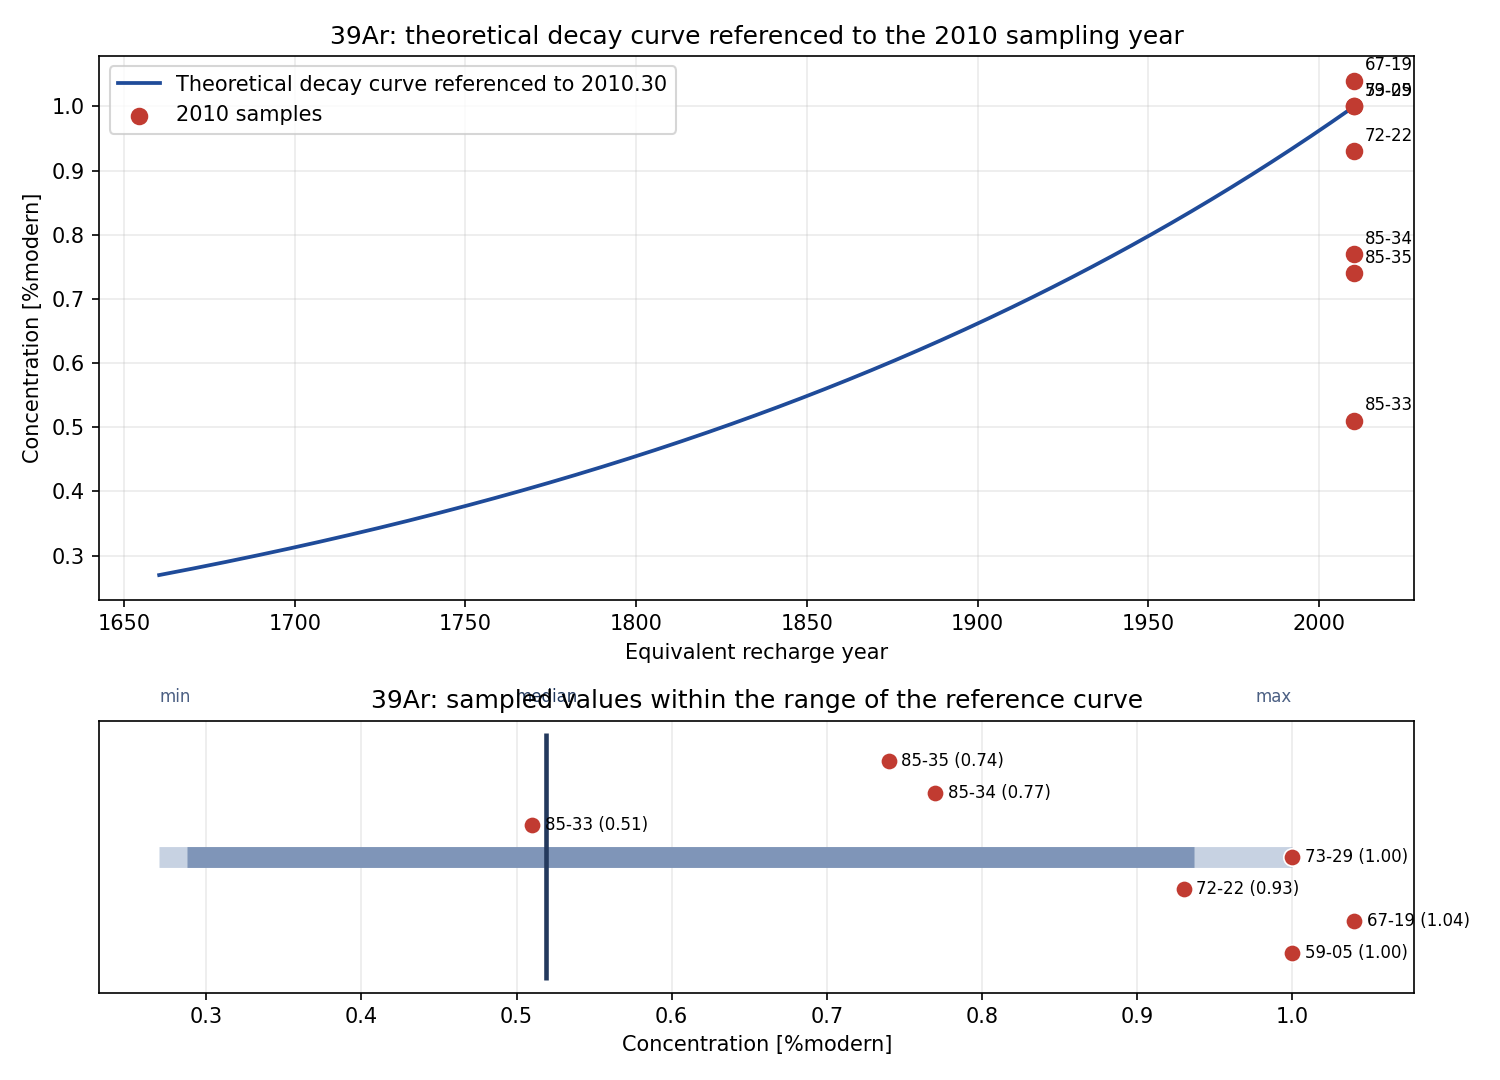

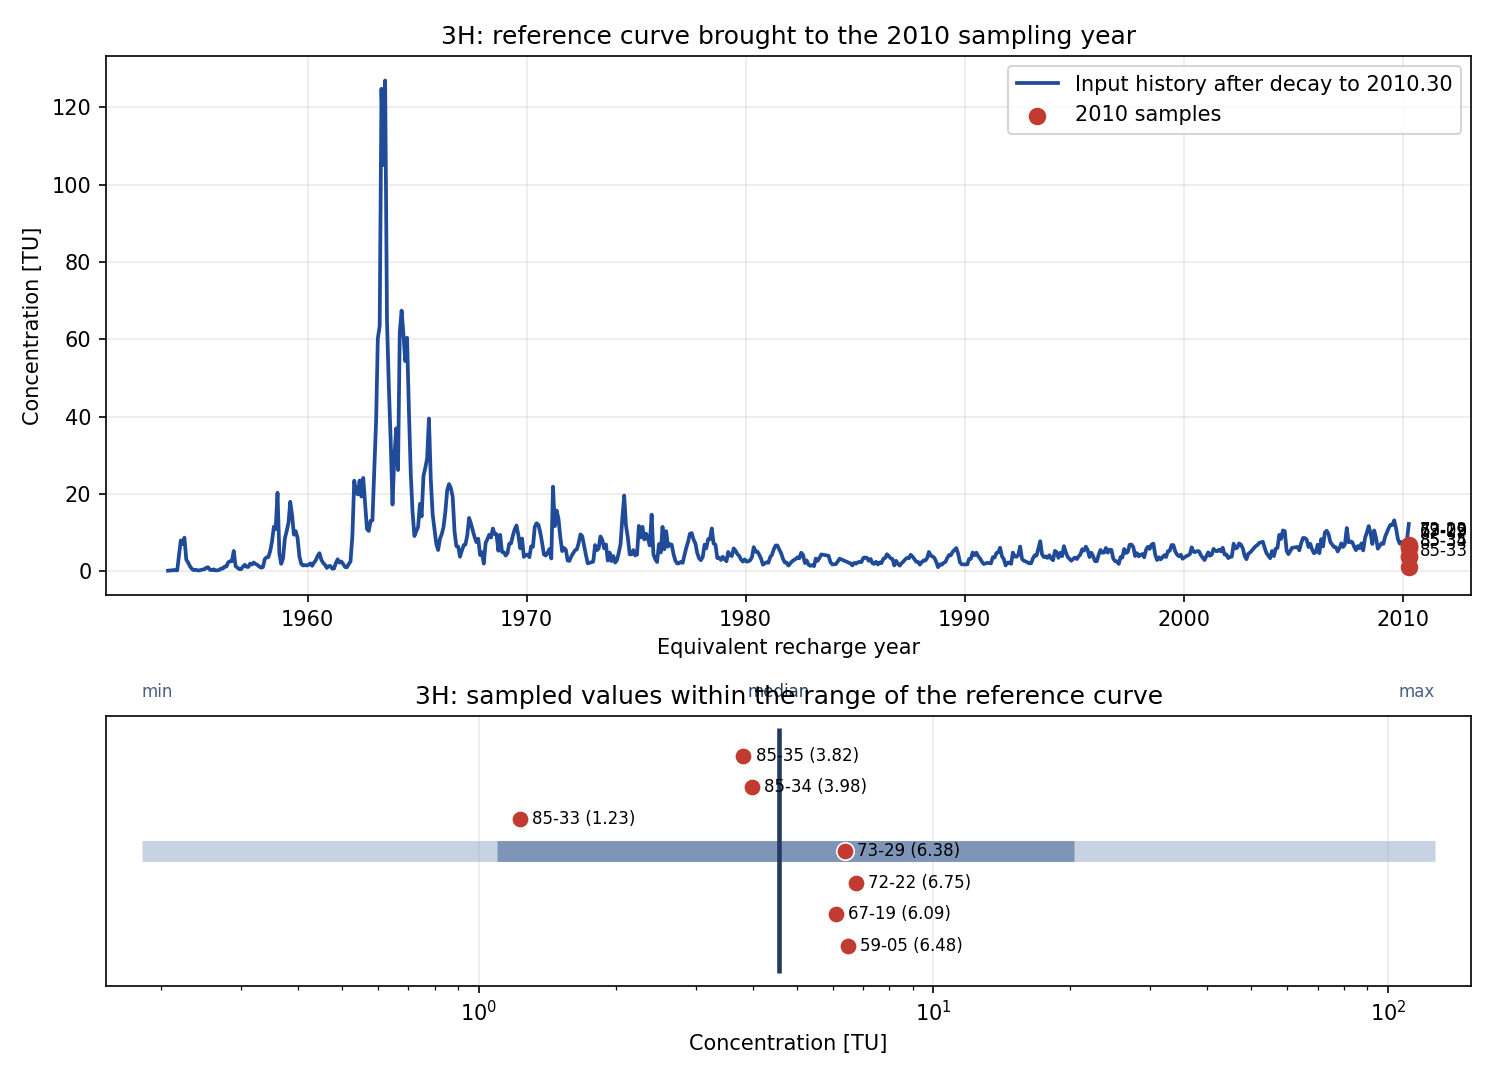

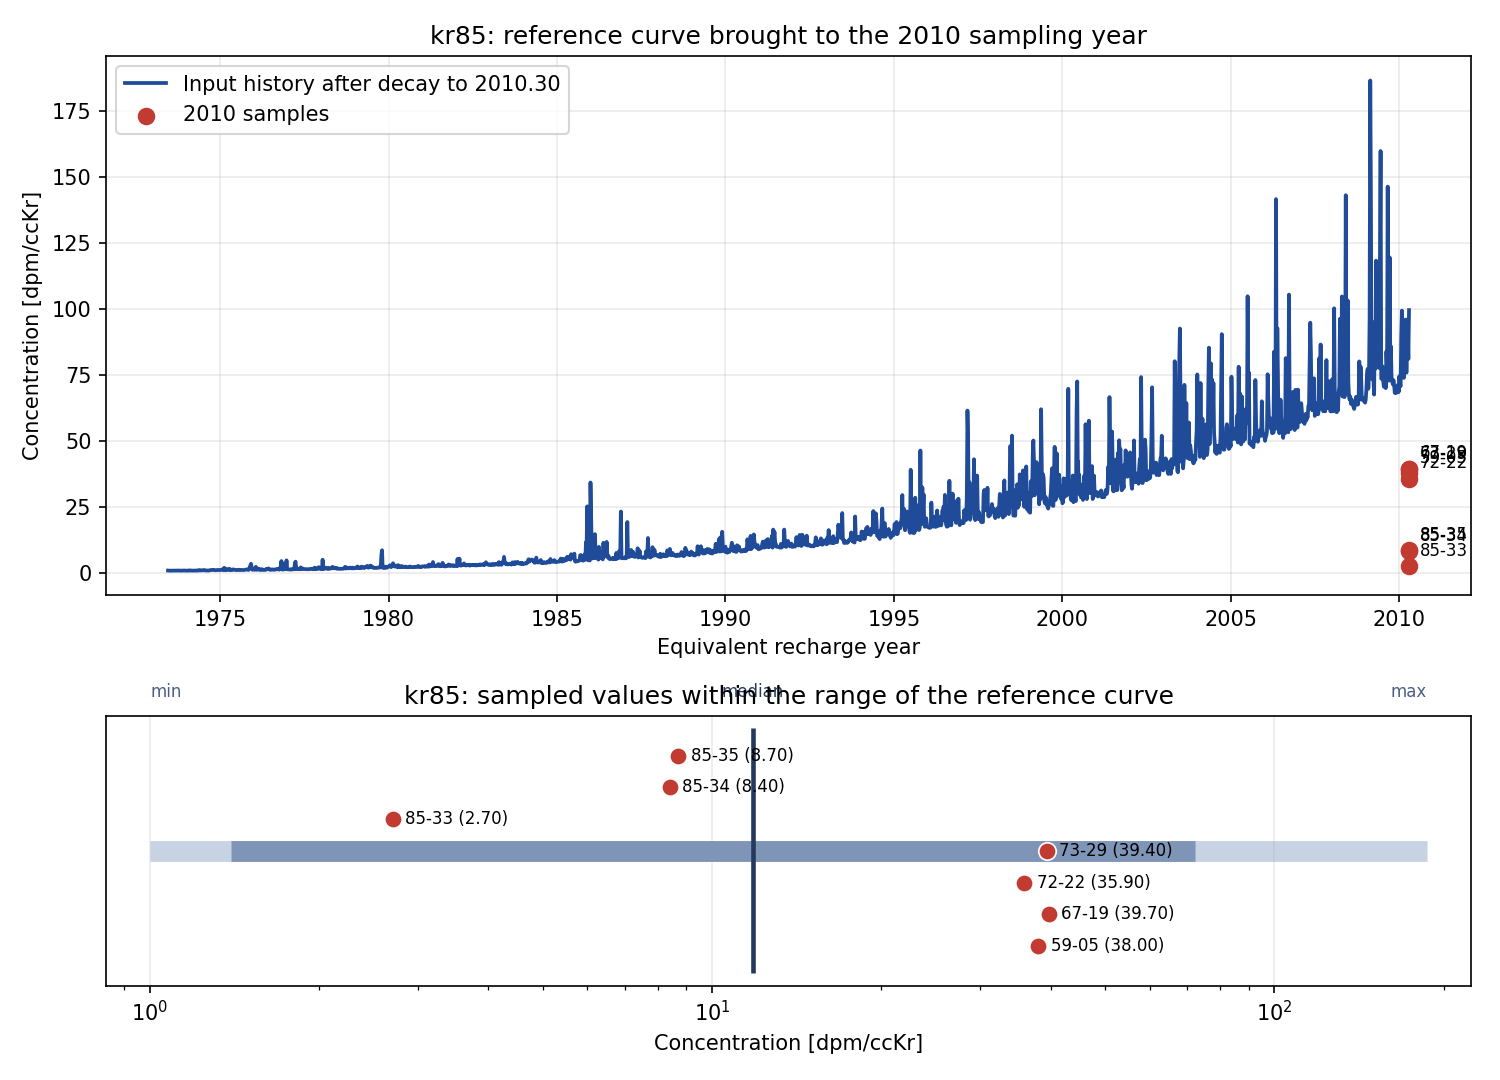

In [6]:
for path in sorted(pre_model_dir.glob("tracer_*_history_and_observations.png")):
    display(Image(filename=str(path), width=900))


### Well-by-well view

These panels transpose the same information well by well. They are useful for one specific question: *does one well systematically look younger or older across the three tracers at the same time?*


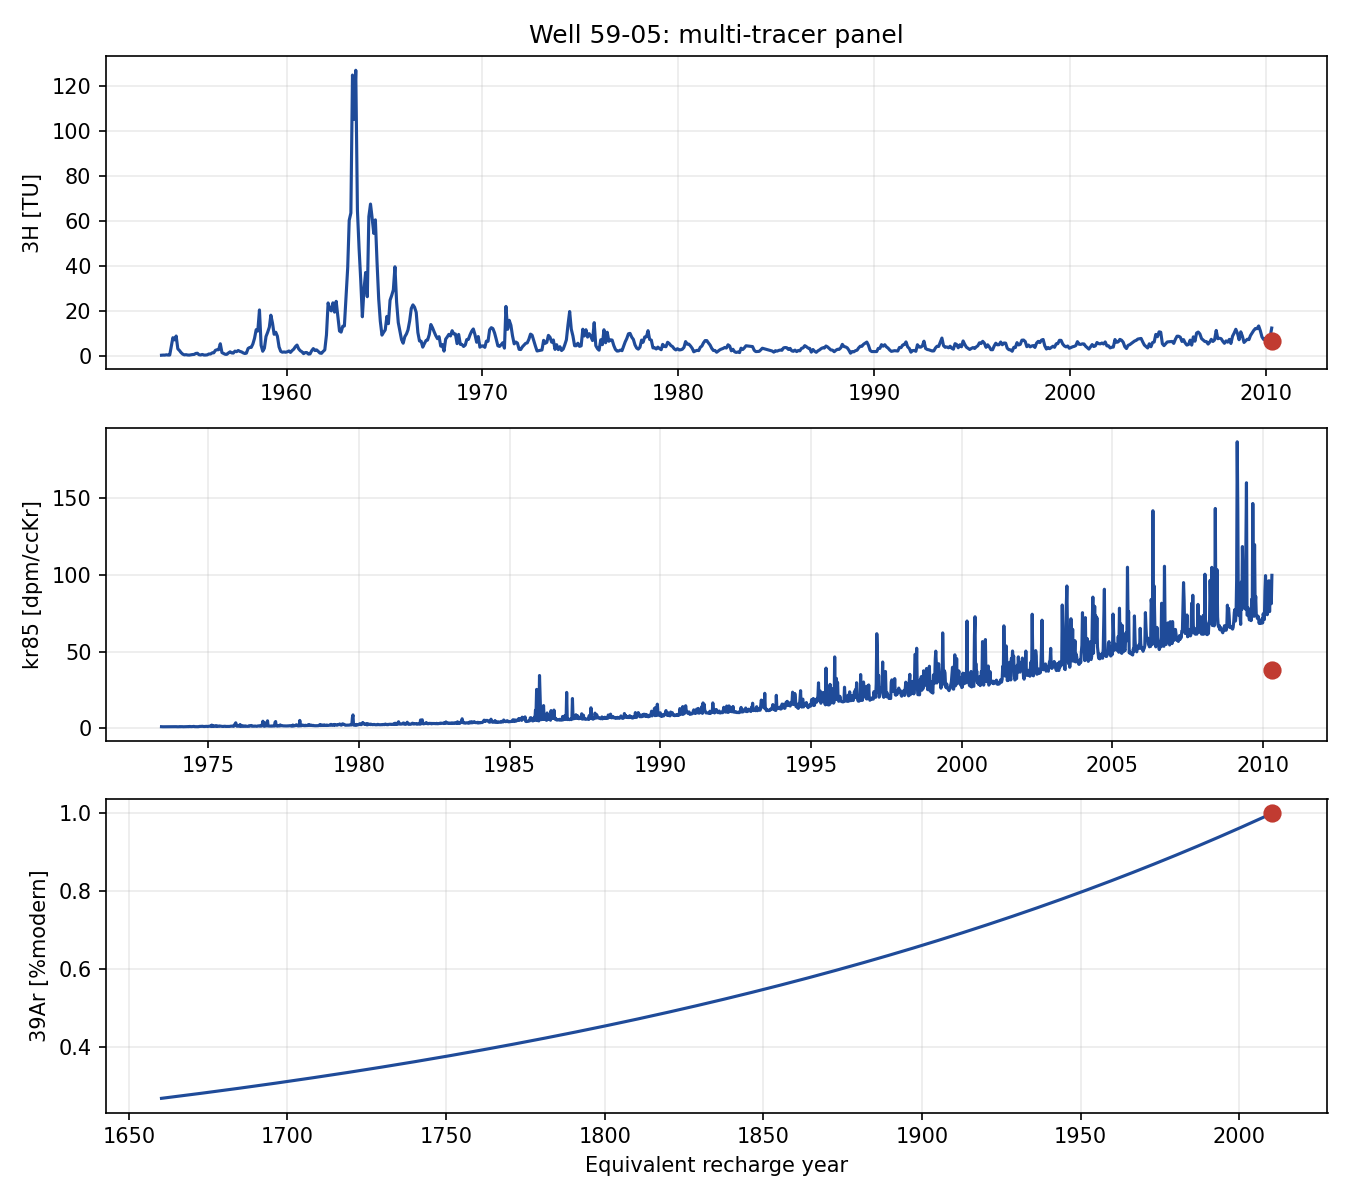

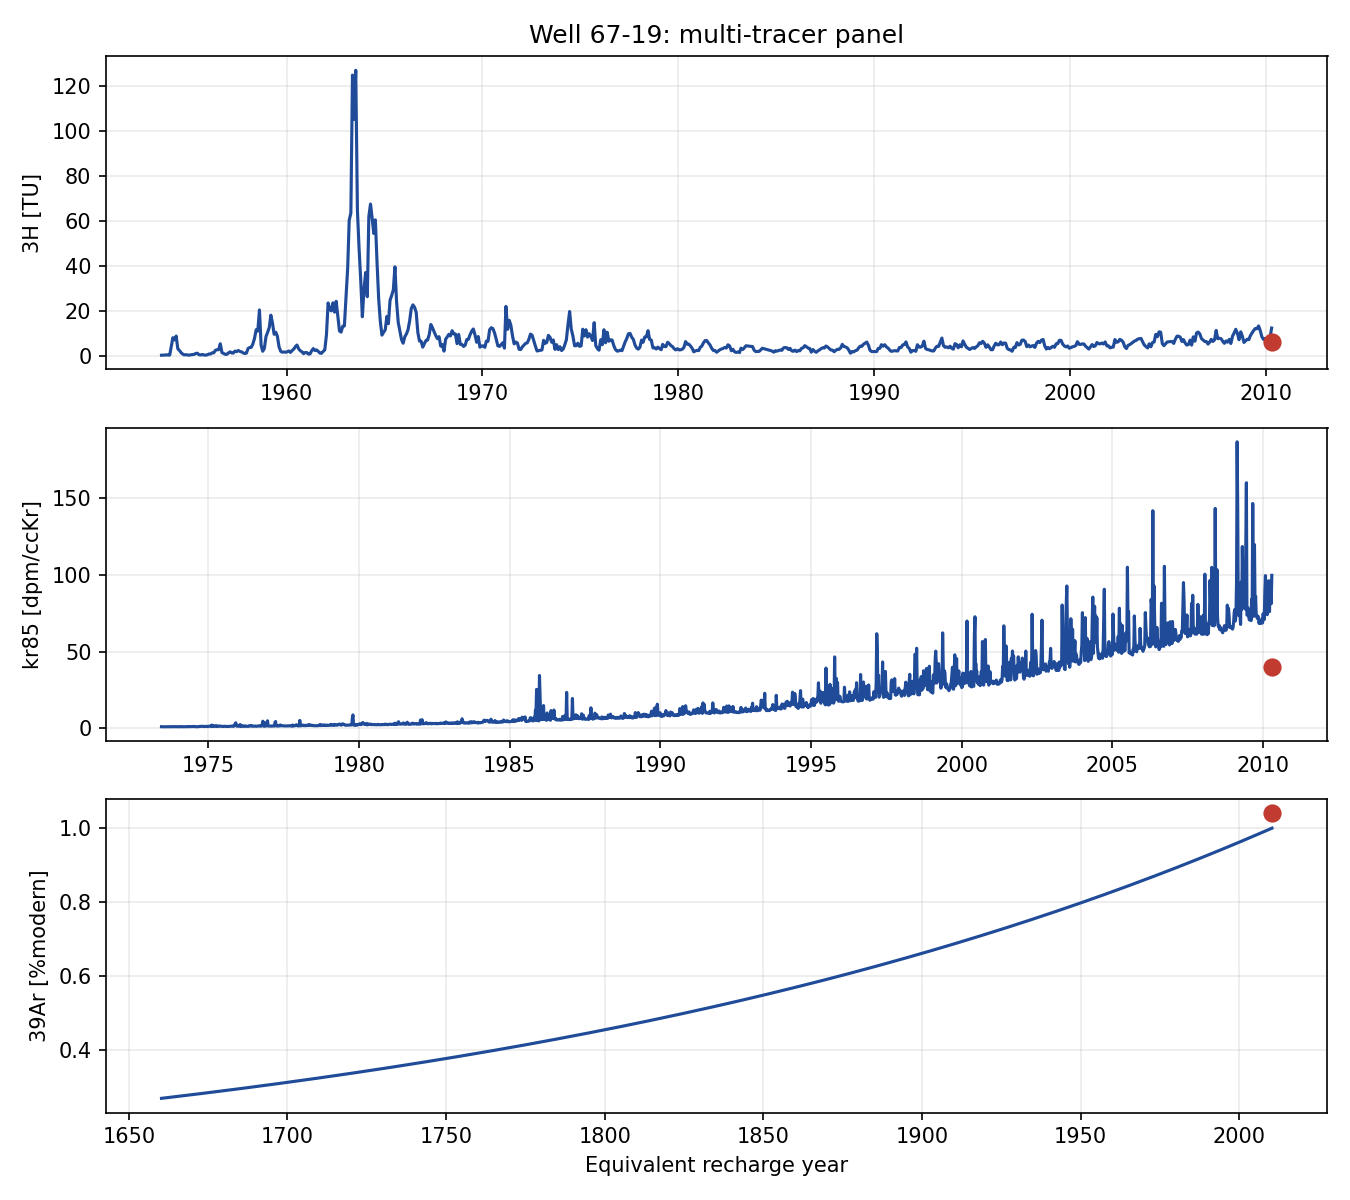

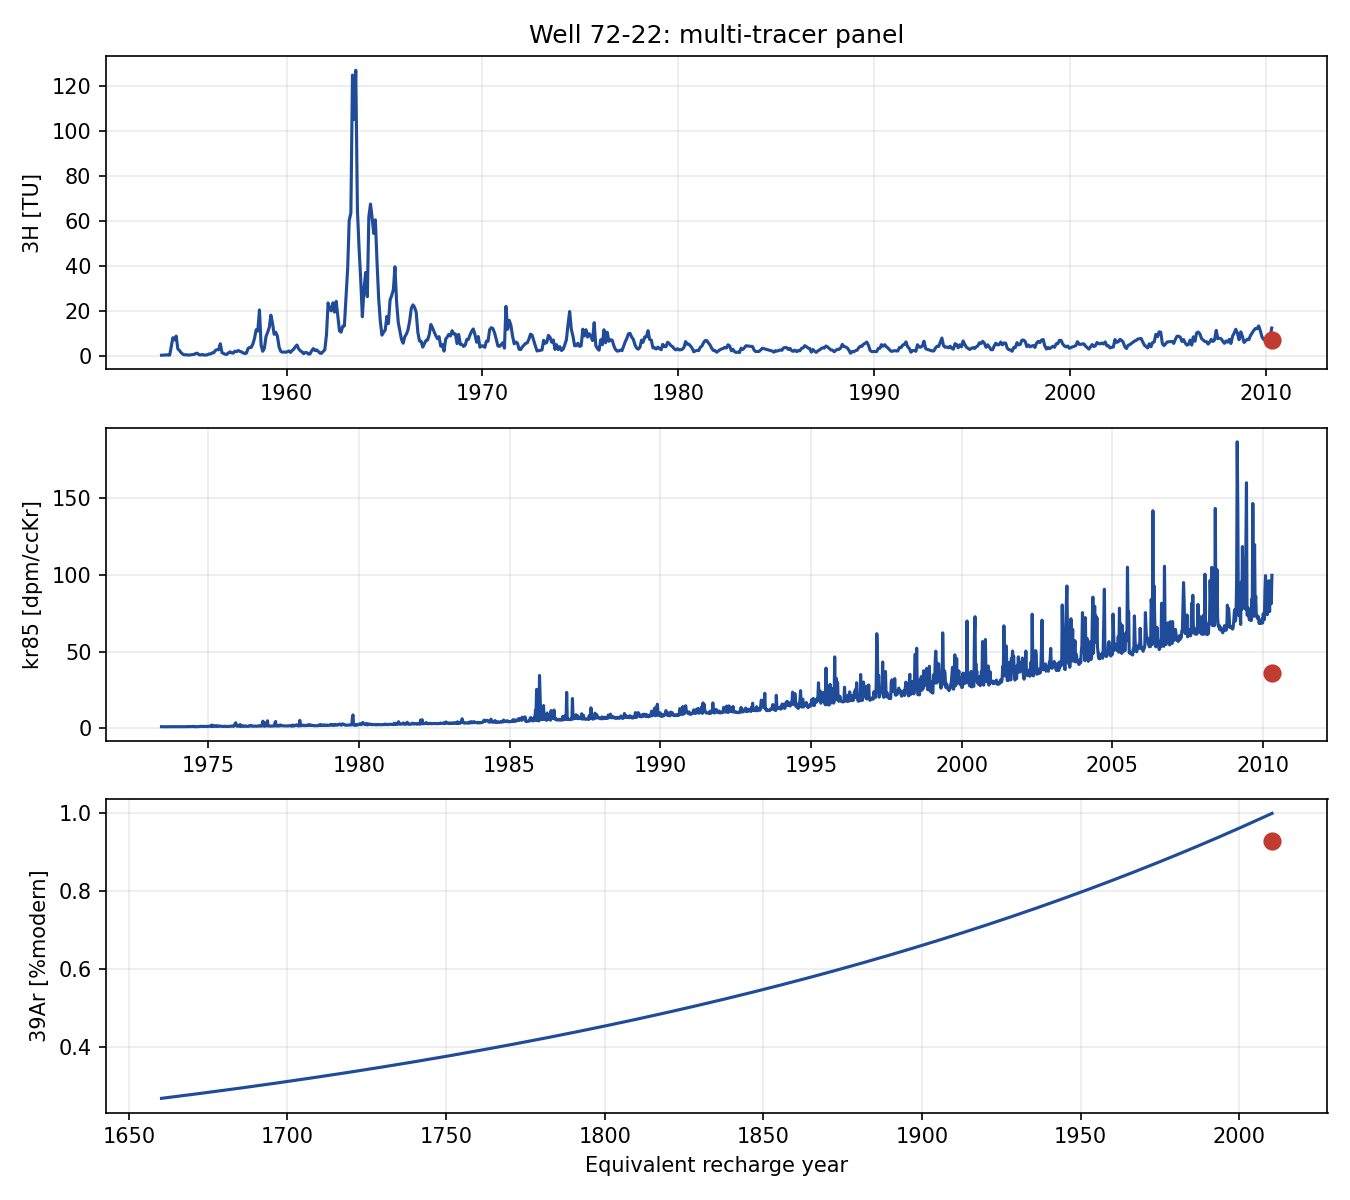

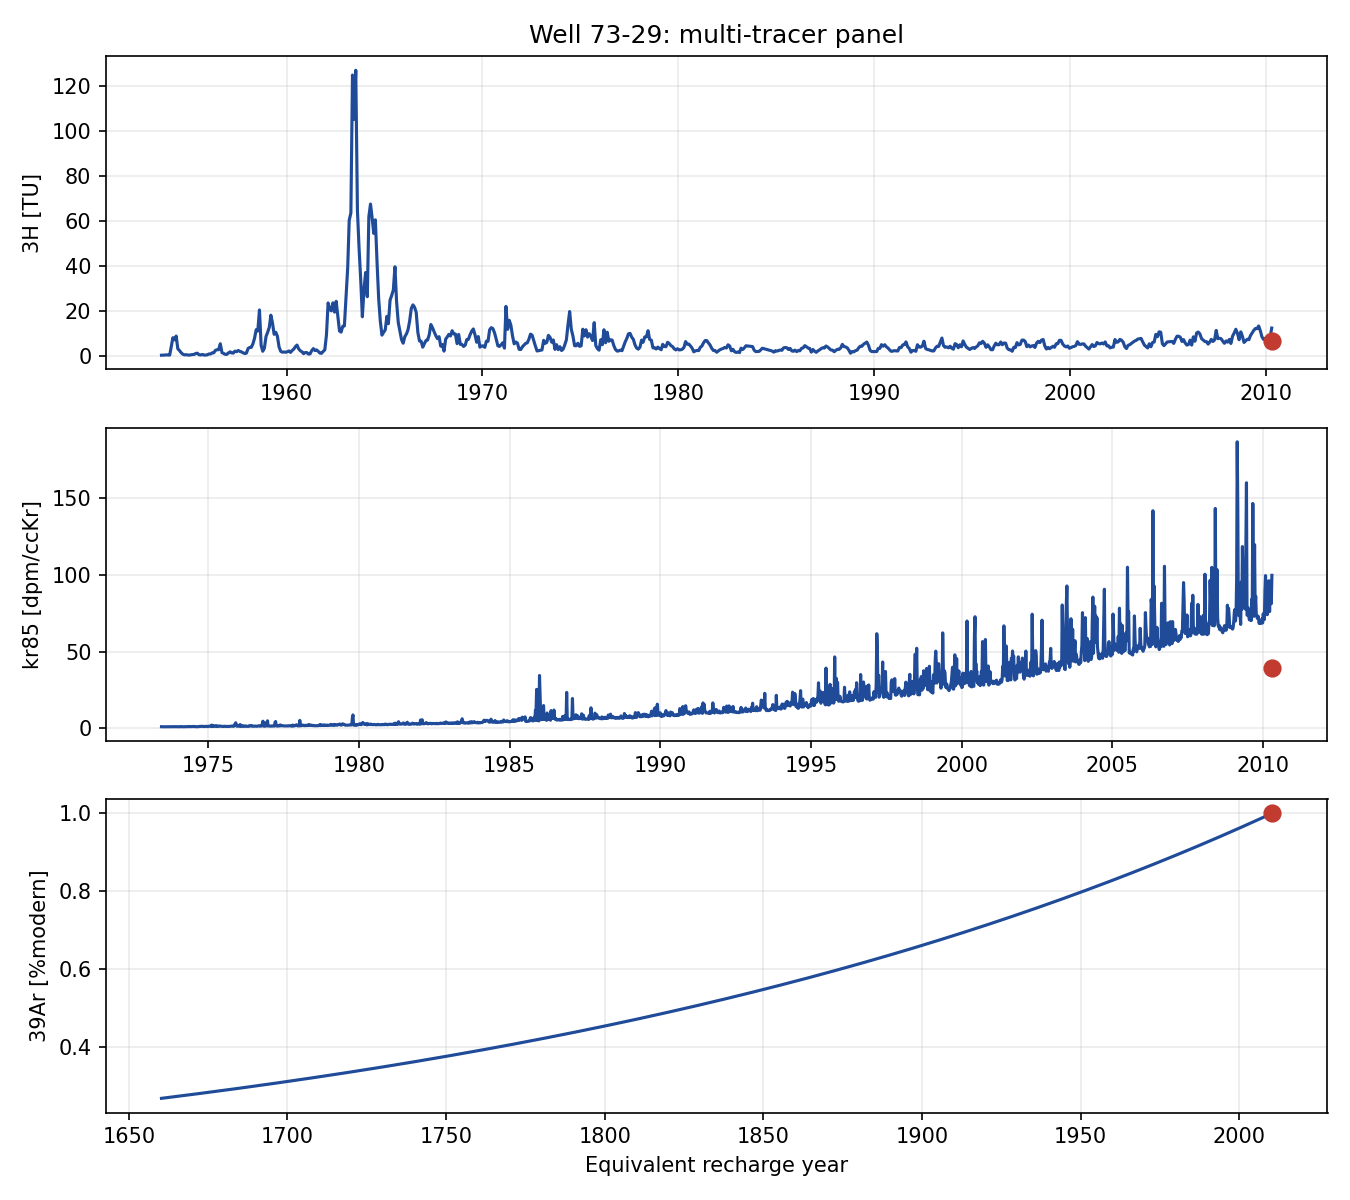

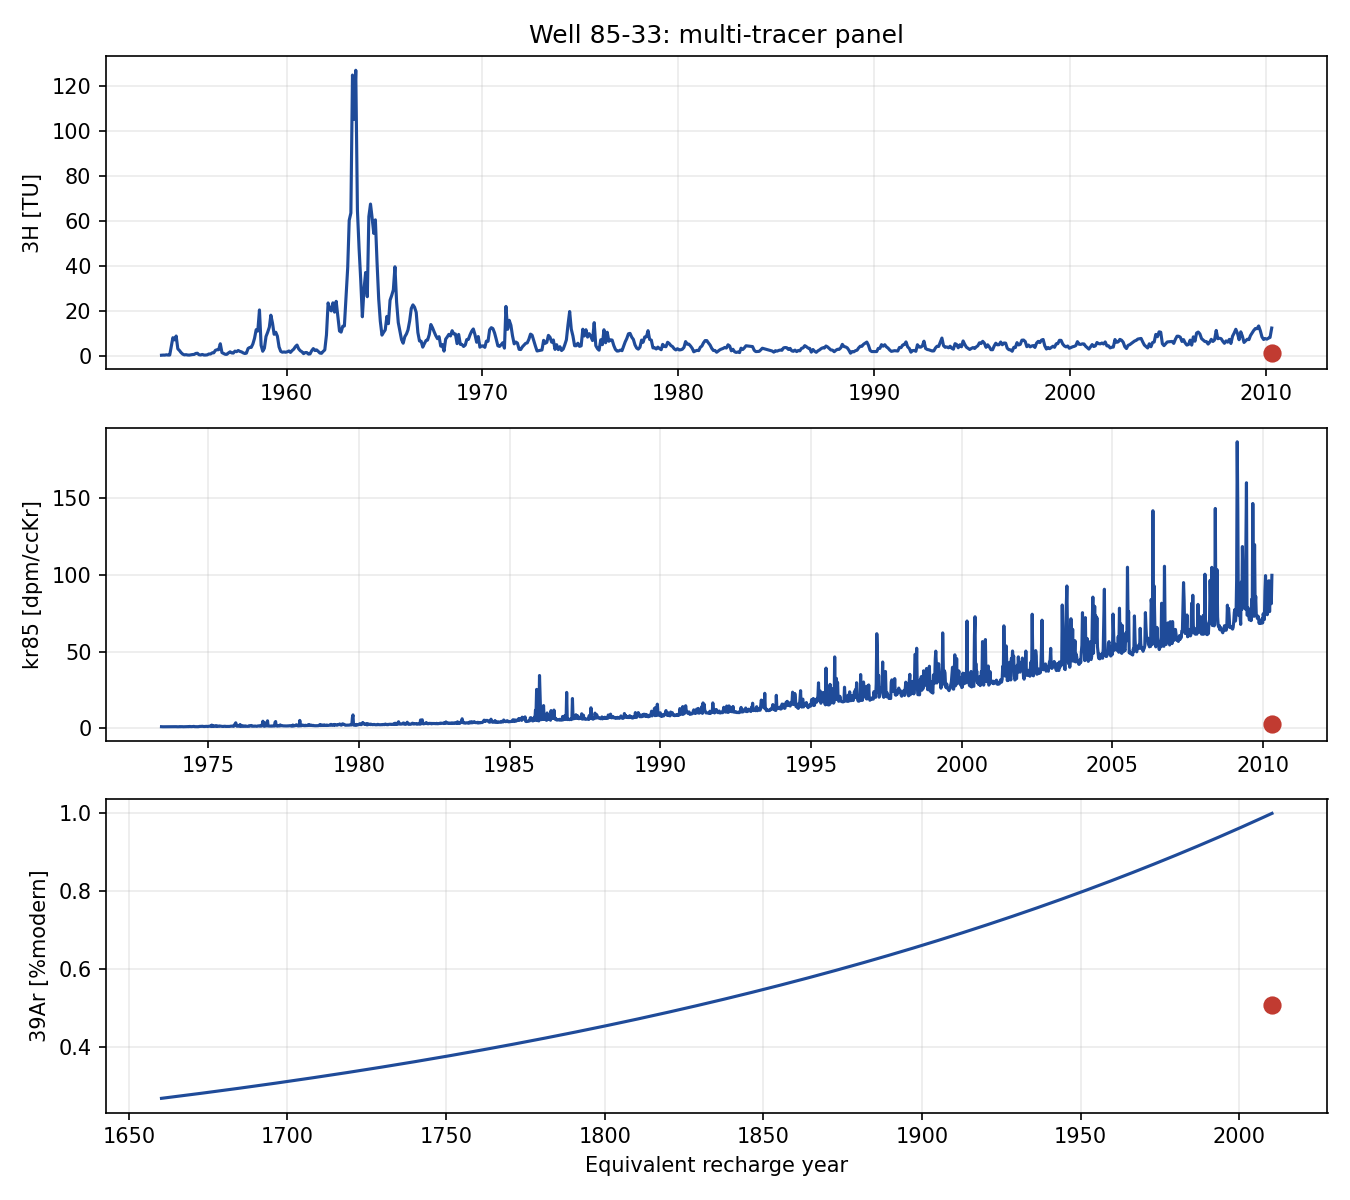

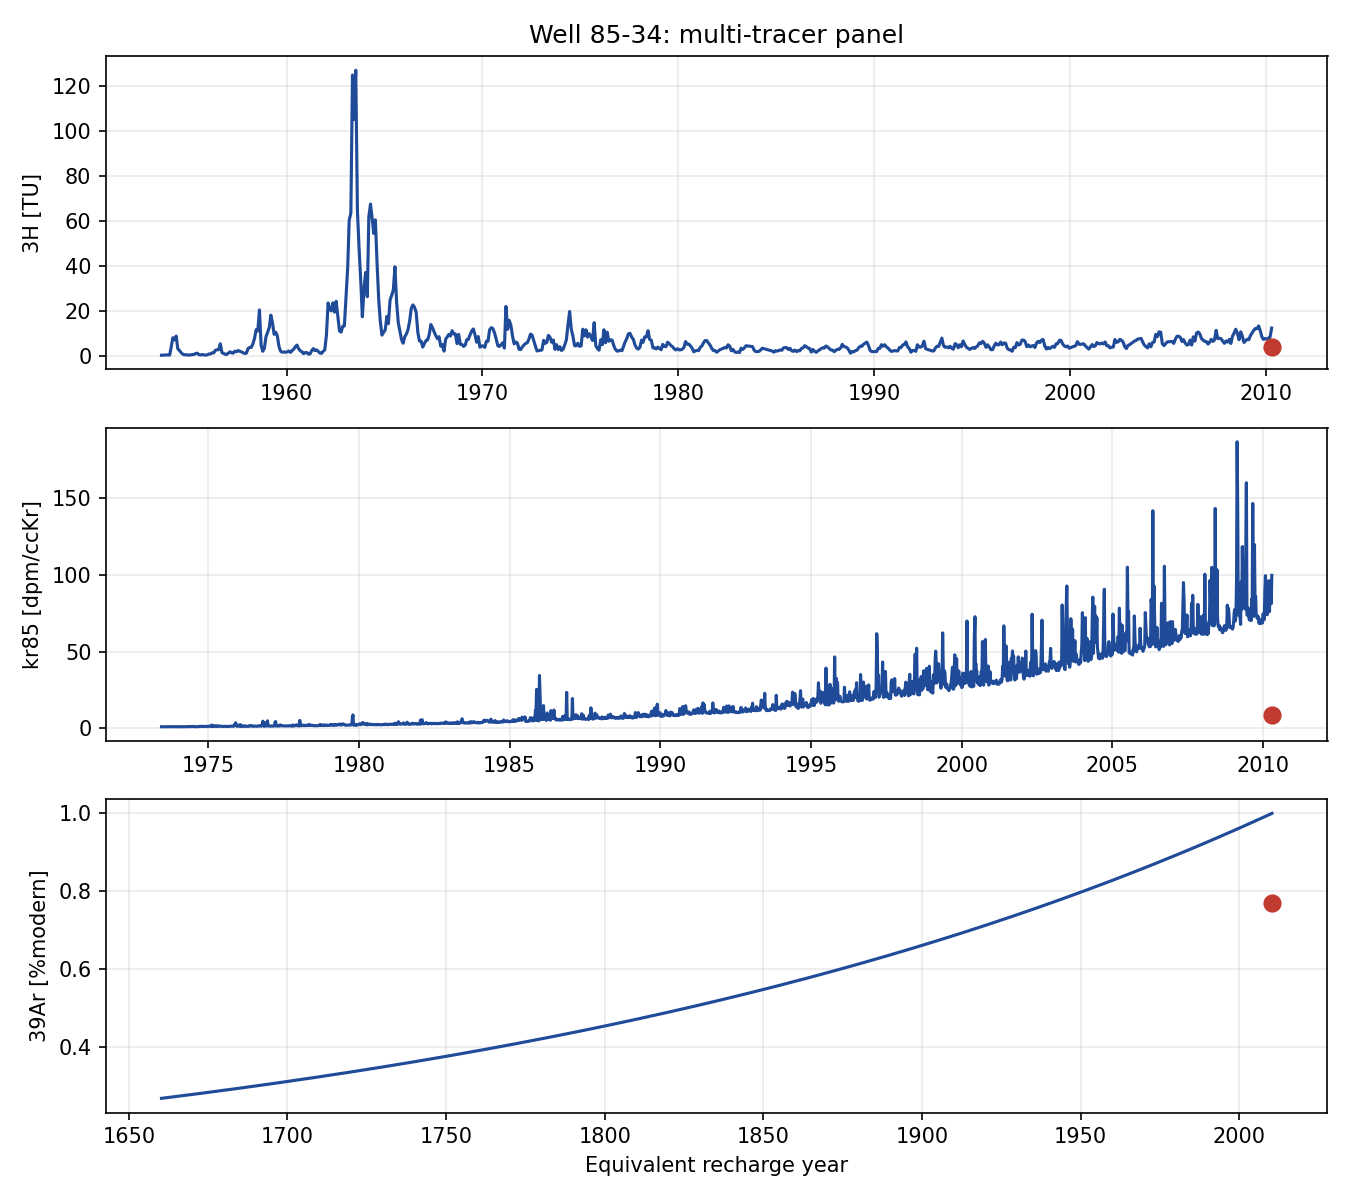

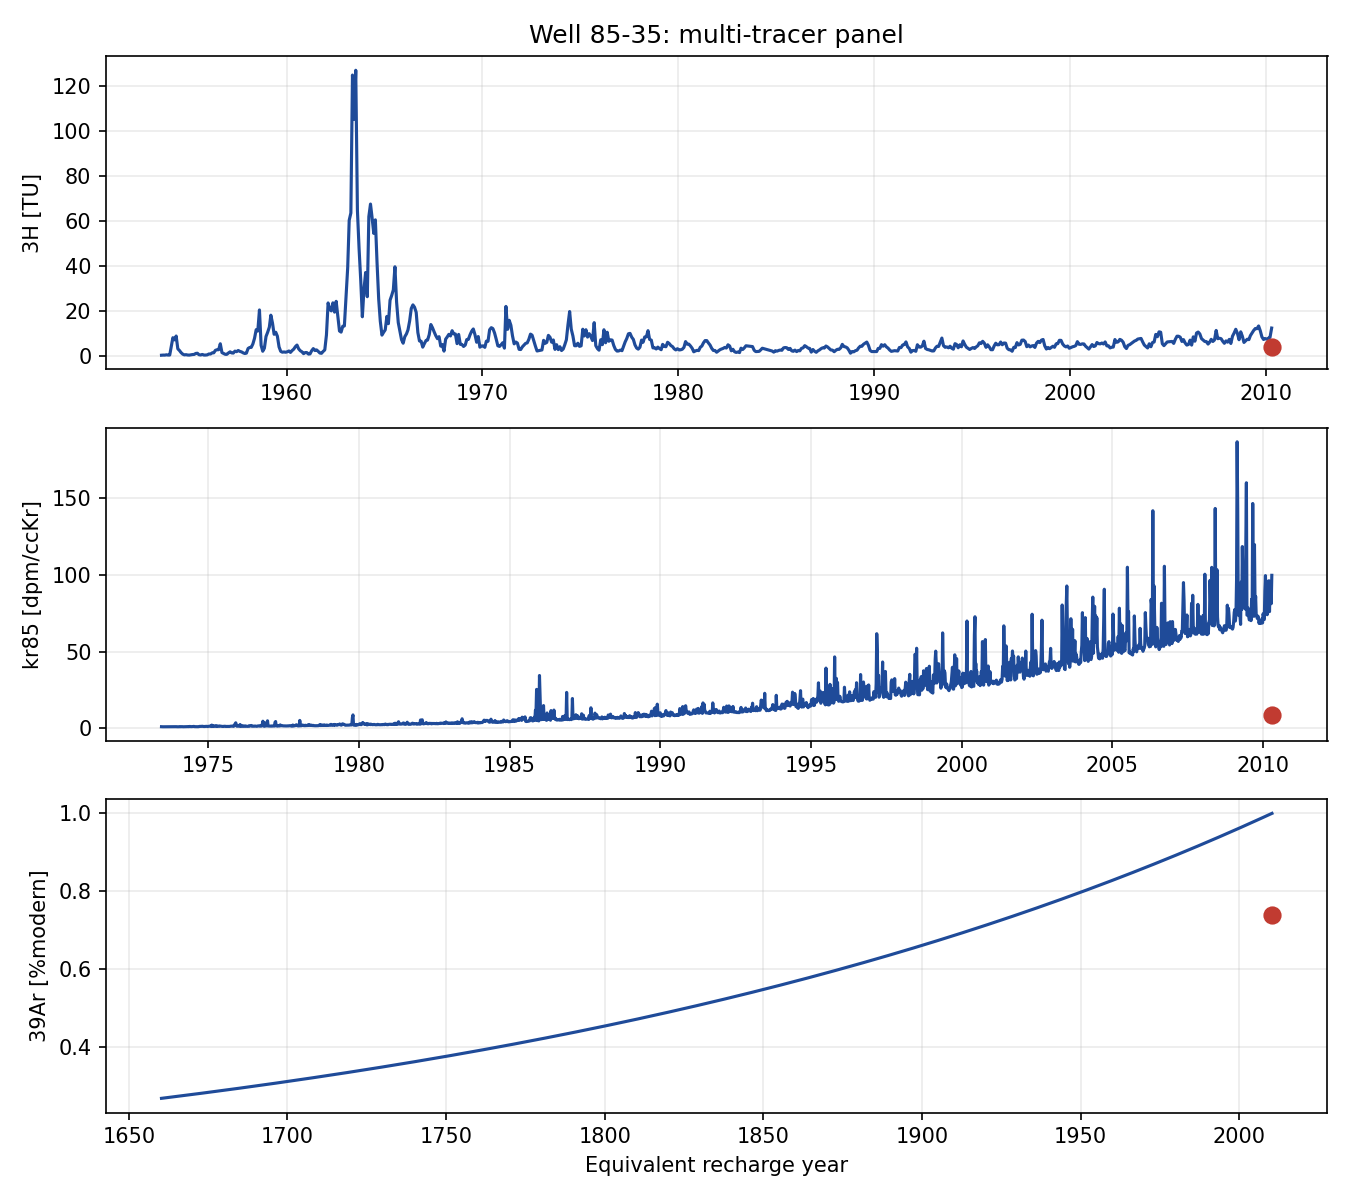

In [7]:
for path in sorted(pre_model_dir.glob("well_*_multi_tracer_panel.png")):
    display(Image(filename=str(path), width=860))


### 3H/3He and helium diagnostic view

These figures are not calibration results. They are the interpretation layer that was missing before:
- the first panel rebuilds an initial tritium indicator from `3H + 3He_trit`;
- the second panel places reported `3H/3He` apparent age against `He4_terr`, with `DeltaNe_pct` kept visible as a screening context;
- the ratio check compares the reported `3H/3He` apparent age with the value reconstructed directly from `3He_trit / 3H`.

Read them as consistency checks and scientific context for the seven selected production wells, with `59-05` included through the documented local `3He_err` fallback.

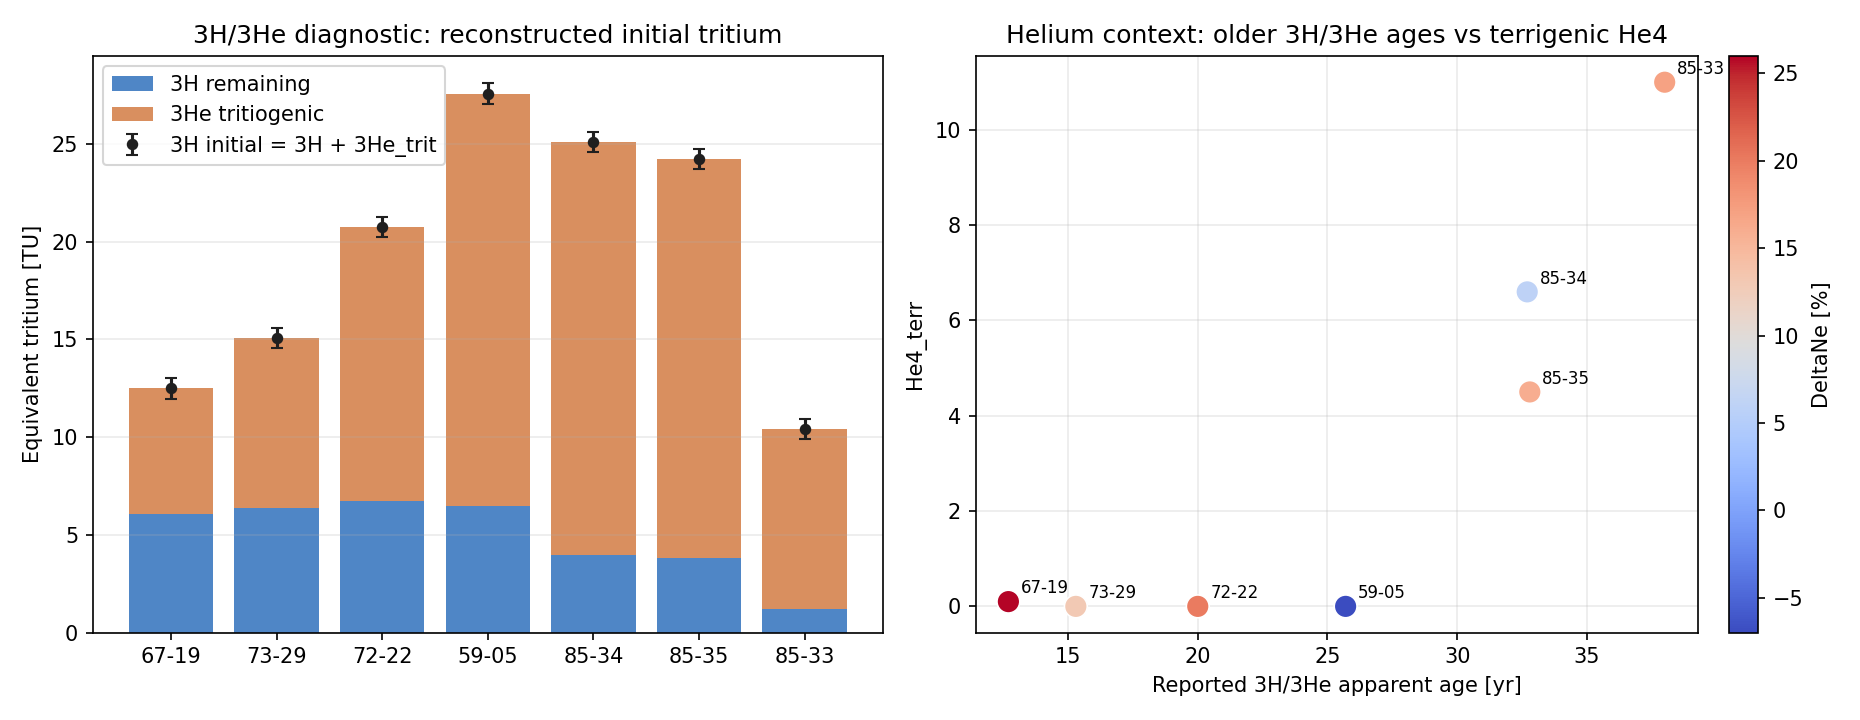

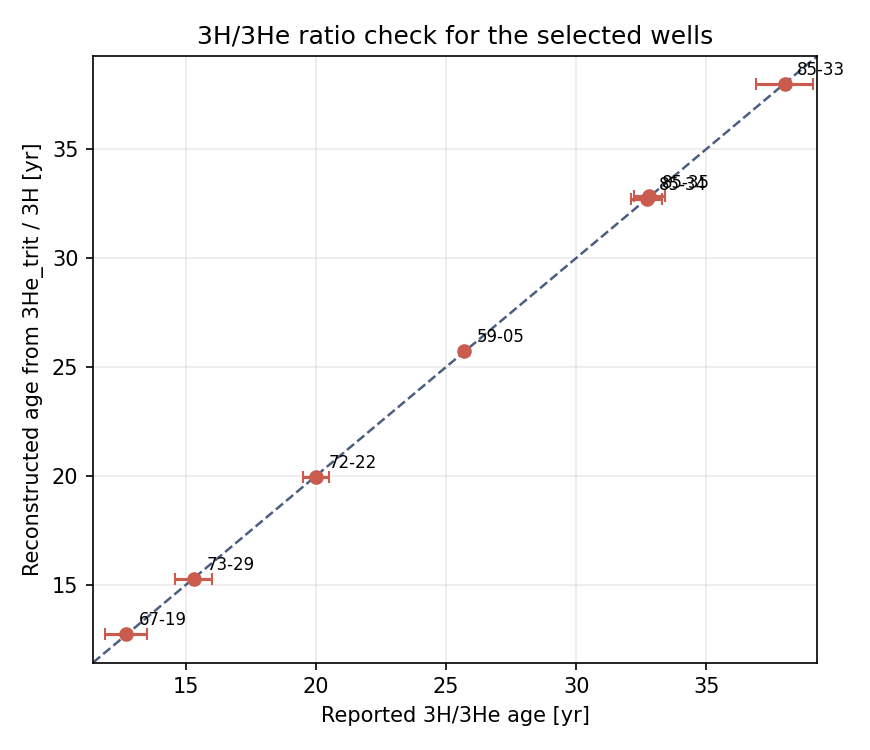

In [8]:
for name in ["helium_3h3he_diagnostic_panel.png", "helium_ratio_age_check.png"]:
    display(Image(filename=str(pre_model_dir / name), width=900))

## 4. Figures from the paper used as anchors

The next images are cropped directly from the local PDF of Visser et al. (2013). They act as anchors for interpretation.

Why these figures matter here:
- **Figure 4** reminds us that the `3H` story begins with the historical input pulse, not with a single measured well value;
- **Figure 8** shows why helium remains an interpretation topic rather than a V1 calibration target in this example;
- **Figure 9** is especially important because it links tracer-tracer behavior to the discrete `4-bin` logic adopted in the paper;
- **Figure 10** shows how the paper compares age-distribution model families.


In [9]:
article_dir = ctx.paths.benchmark_dir / "article_reference"
if not list(article_dir.glob("figure_*.png")):
    try:
        build_article_reference_figures(ctx, article_dir)
    except Exception as exc:
        print(f"Article figure extraction skipped: {exc}")
article_dir


WindowsPath('C:/codes/pyage/examples/natural/holten/generated/benchmark/article_reference')

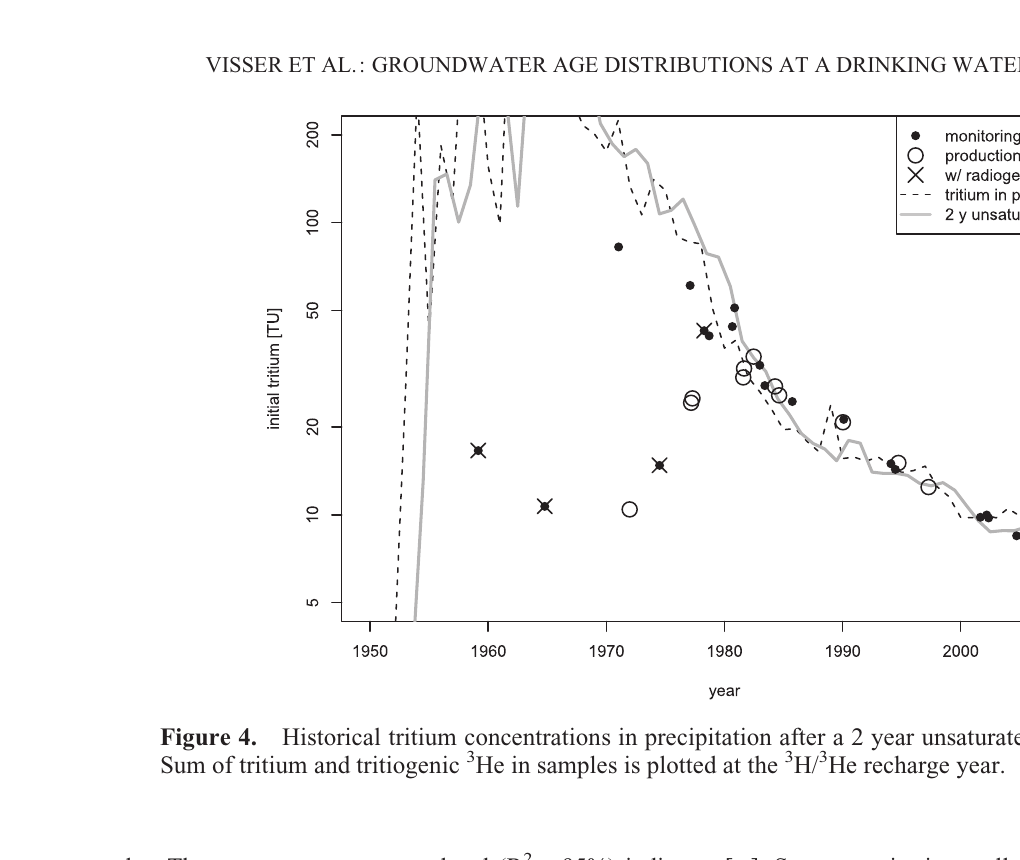

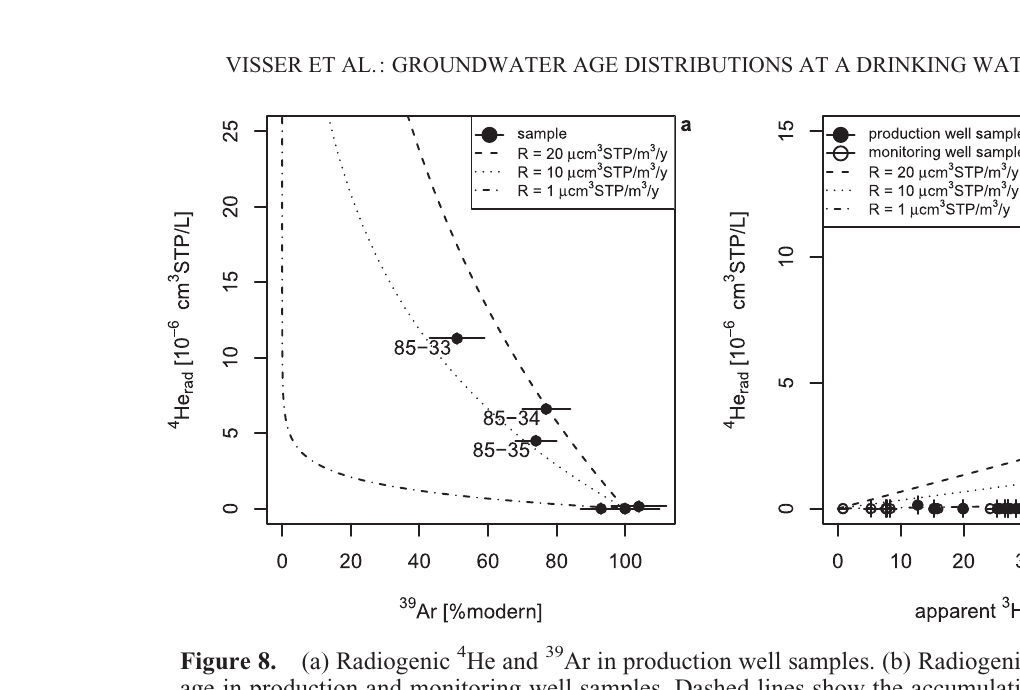

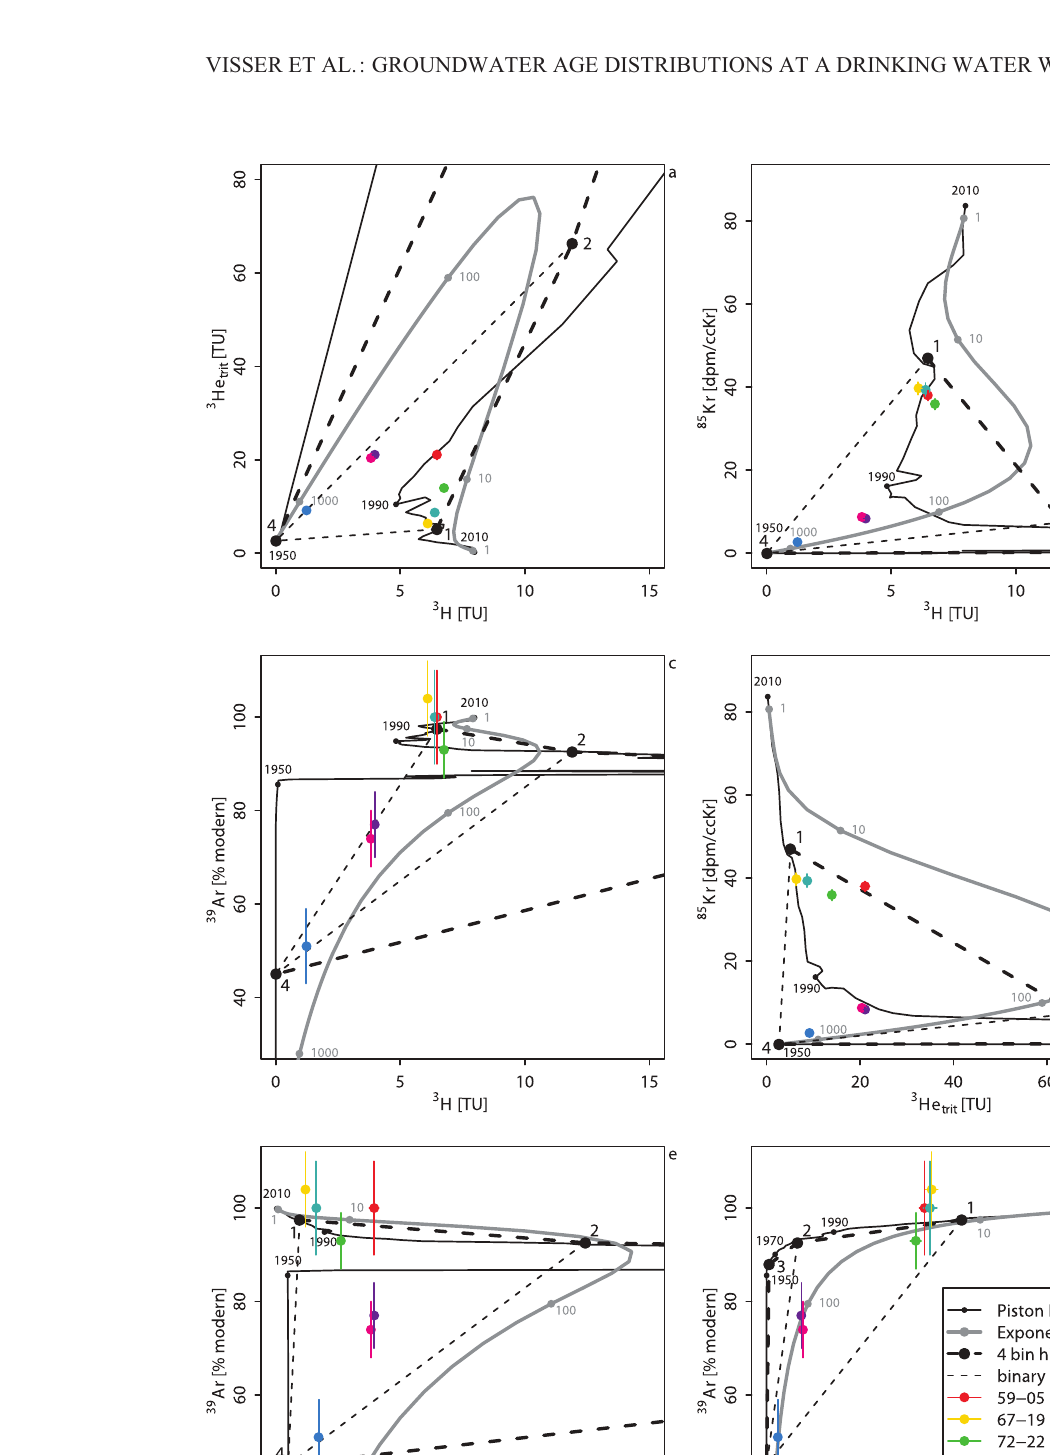

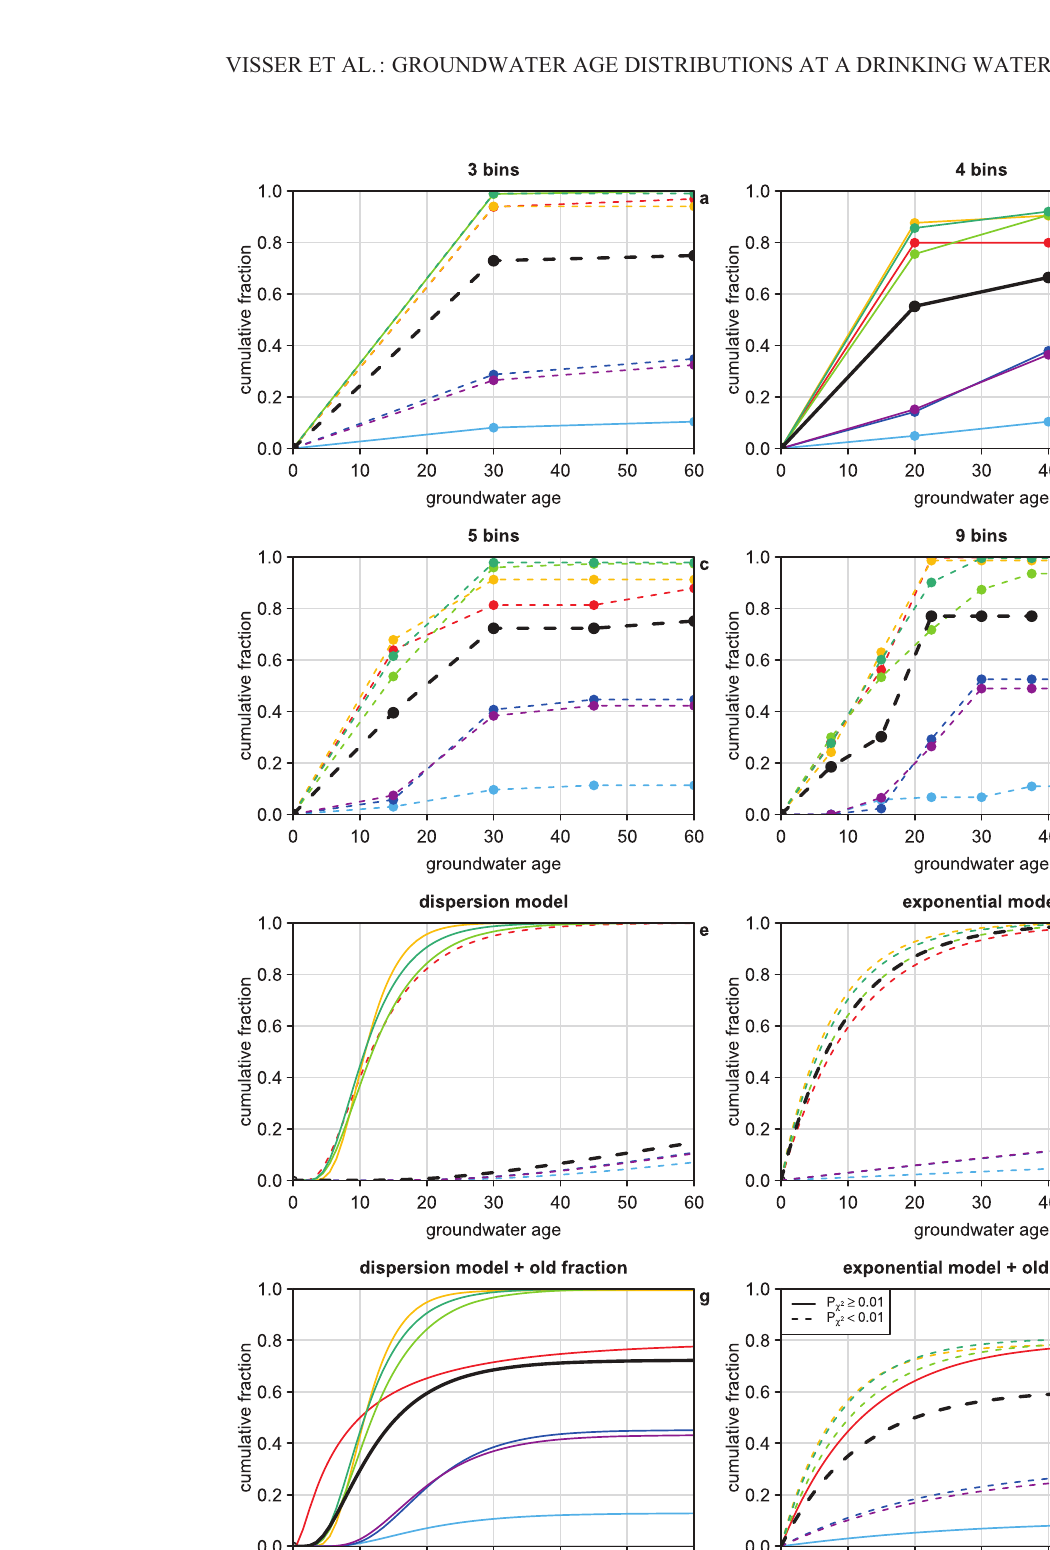

In [10]:
for name in ["figure_4.png", "figure_8.png", "figure_9.png", "figure_10.png"]:
    path = article_dir / name
    if path.exists():
        display(Image(filename=str(path), width=920))


## 5. Local article-style 4-bin fit

This example includes a Holten-specific local helper that fits four fractions:
- `0-20 years`
- `20-40 years`
- `40-60 years`
- `>60 years` (`old` fraction)

This is intentionally local to the Holten example for now. The reason is scientific rather than technical: the `old` component is tracer-specific in the way the paper is interpreted here, so it should not yet be pushed blindly into a generic repository-wide LPM.

The local fit now uses four tracer constraints for each well: `3H`, `3He_trit`, `kr85`, and `39Ar`.


In [11]:
four_bin_dir = ctx.paths.benchmark_dir / "four_bin"
local_4bin_endmembers, local_4bin_summary, local_4bin_fit, four_bin_paths = run_local_4bin(prepared, four_bin_dir)
local_4bin_summary.round(4)


,well_id,n_observations_local_4bin,tracers_local_4bin,f_0_20,f_20_40,f_40_60,f_old,chi2_local_4bin,rmse_local_4bin,weighted_rmse_local_4bin,mean_age_local_4bin,optimization_success,optimization_message
0,59-05,4,"3H,3He_trit,kr85,39Ar",0.9655,0.0000,0.0345,0.0000,34.2763,0.7351,2.9273,11.3796,True,Optimization terminated successfully.
1,67-19,4,"3H,3He_trit,kr85,39Ar",1.0000,0.0000,0.0000,0.0000,16.5152,0.8597,2.0319,10.0000,True,Optimization terminated successfully.
2,72-22,4,"3H,3He_trit,kr85,39Ar",0.9821,0.0000,0.0179,0.0000,53.2180,0.9498,3.6475,10.7147,True,Optimization terminated successfully.
3,73-29,4,"3H,3He_trit,kr85,39Ar",0.9948,0.0000,0.0052,0.0000,28.2767,0.8644,2.6588,10.2086,True,Optimization terminated successfully.
4,85-33,4,"3H,3He_trit,kr85,39Ar",0.0740,0.1233,0.0000,0.8028,38.4320,0.8377,3.0997,253.2919,True,Optimization terminated successfully.
5,85-34,4,"3H,3He_trit,kr85,39Ar",0.2742,0.3047,0.0000,0.4212,136.3917,1.7614,5.8393,142.4394,True,Optimization terminated successfully.
6,85-35,4,"3H,3He_trit,kr85,39Ar",0.2344,0.2977,0.0000,0.4679,133.4797,1.1519,5.7767,156.3186,True,Optimization terminated successfully.


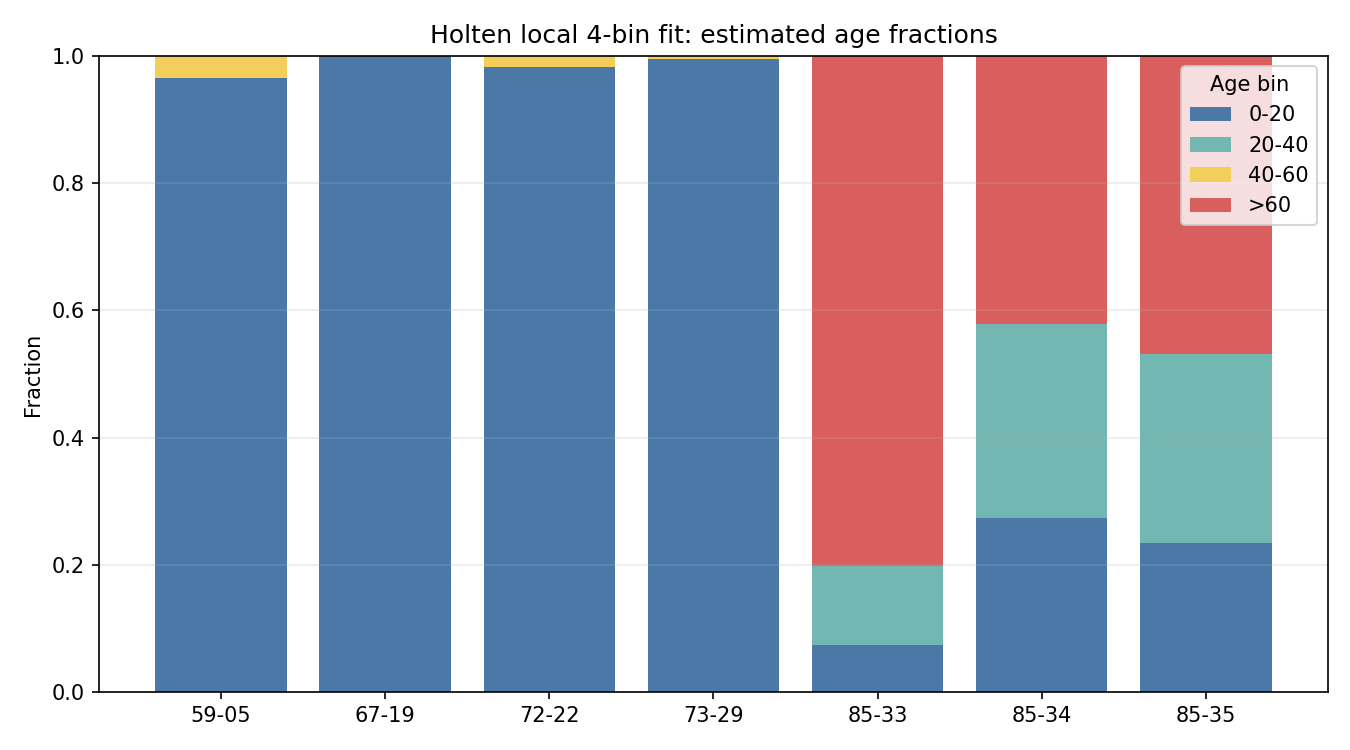

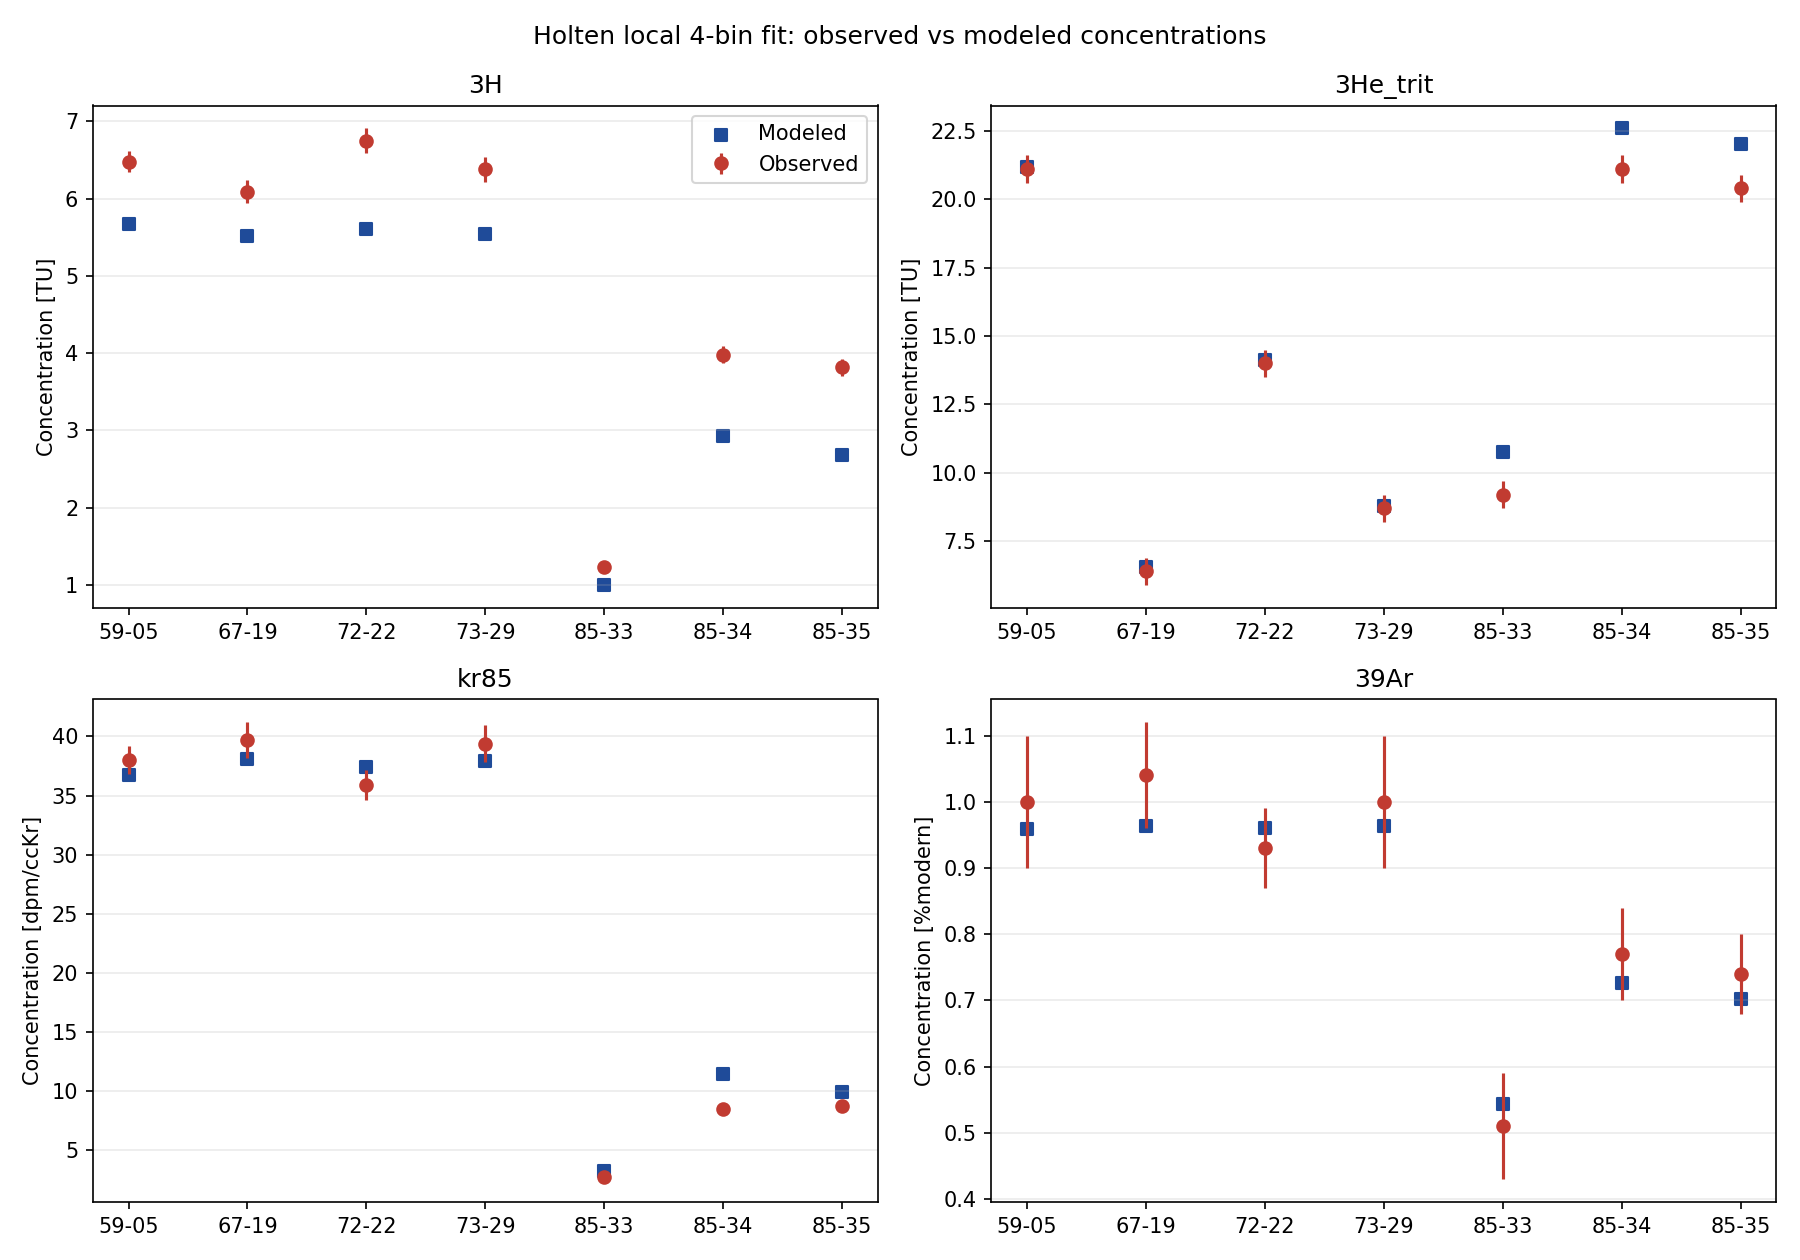

In [12]:
for name in ["holten_4bin_fractions.png", "holten_4bin_observed_vs_modeled.png"]:
    display(Image(filename=str(four_bin_dir / name), width=900))


## 6. Paper 4-bin parameters vs local Metropolis-Hastings posterior

This is the key comparison for the Holten notebook.

The paper provides discrete `4-bin` cumulative age distributions in the `Shape-free_models` sheet of `visser_data.xlsx`. For the seven production wells used here, those cumulative values can be converted into four fractions:
- `f_0_20`
- `f_20_40`
- `f_40_60`
- `f_old`

The local Holten Metropolis-Hastings calibration shown below samples those same four fractions through the three free parameters of the constrained `4-bin` model. This is why it is a meaningful parameter comparison, unlike a comparison of `chi2` values alone.

This notebook no longer relies on the old benchmark-comparison import path. It uses only the current local Holten helpers required for the parameter comparison.


In [13]:
paper_4bin, mh_posterior, paper_vs_mh, mh_paths = run_local_4bin_mh(prepared, four_bin_dir)
paper_4bin.round(4)


,well_id,f_0_20,f_20_40,f_40_60,f_old
0,59-05,0.8023,0.0000,0.0452,0.1525
1,67-19,0.8814,0.0226,0.0000,0.0960
2,72-22,0.7571,0.1469,0.0000,0.0960
3,73-29,0.8588,0.0621,0.0000,0.0791
4,85-33,0.0452,0.0565,0.0169,0.8814
5,85-34,0.1412,0.2430,0.0056,0.6102
6,85-35,0.1525,0.2147,0.0057,0.6271


The next table is the compact comparison view: paper value, posterior median, and posterior `q10-q90` interval for each fraction.


In [14]:
paper_vs_mh.round(4)


,well_id,f_0_20_paper,f_0_20_posterior_median,f_0_20_posterior_q10,f_0_20_posterior_q90,f_20_40_paper,f_20_40_posterior_median,f_20_40_posterior_q10,f_20_40_posterior_q90,f_40_60_paper,f_40_60_posterior_median,f_40_60_posterior_q10,f_40_60_posterior_q90,f_old_paper,f_old_posterior_median,f_old_posterior_q10,f_old_posterior_q90
0,59-05,0.8023,0.9656,0.9640,0.9671,0.0000,0.0000,0.0000,0.0000,0.0452,0.0344,0.0329,0.0360,0.1525,0.0000,0.0000,0.0000
1,67-19,0.8814,1.0000,1.0000,1.0000,0.0226,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0960,0.0000,0.0000,0.0000
2,72-22,0.7571,0.9821,0.9808,0.9837,0.1469,0.0000,0.0000,0.0000,0.0000,0.0179,0.0163,0.0192,0.0960,0.0000,0.0000,0.0000
3,73-29,0.8588,0.9952,0.9937,0.9966,0.0621,0.0000,0.0000,0.0000,0.0000,0.0048,0.0034,0.0063,0.0791,0.0000,0.0000,0.0000
4,85-33,0.0452,0.0736,0.0671,0.0802,0.0565,0.1227,0.1149,0.1314,0.0169,0.0000,0.0000,0.0000,0.8814,0.8032,0.7945,0.8121
5,85-34,0.1412,0.2740,0.2585,0.2877,0.2430,0.3051,0.2933,0.3152,0.0056,0.0000,0.0000,0.0000,0.6102,0.4216,0.4069,0.4373
6,85-35,0.1525,0.2341,0.2250,0.2437,0.2147,0.2986,0.2887,0.3083,0.0057,0.0000,0.0000,0.0000,0.6271,0.4676,0.4564,0.4793


### How to read the parameter comparison figures

The first figure shows one posterior distribution per well and per fraction.

Read it in this order:
- the red vertical line is the paper value;
- the blue histogram is the local Metropolis-Hastings posterior for the same fraction;
- the text box gives the paper value and the posterior median;
- when the posterior is concentrated extremely close to `0`, the panel explicitly says `posterior near 0` and reports the `q90` value.

This last point matters for Holten. Some fractions are not missing from the calibration: they are simply pushed against the lower boundary by the likelihood. In other words, the sampler still explores them, but almost all accepted values are numerically very small.

The second figure compresses the same information into intervals:
- blue segment: posterior `q10-q90` interval;
- blue point: posterior median;
- red diamond: paper fraction;
- panel x-limits are fixed to `0-1` for all fractions so the largest differences remain visually comparable across wells and bins.

If the red diamond falls well outside the blue interval, the local Holten calibration does not reproduce the paper's preferred fraction for that bin. If the interval itself is collapsed near `0`, that fraction is effectively rejected by the local posterior for that well.


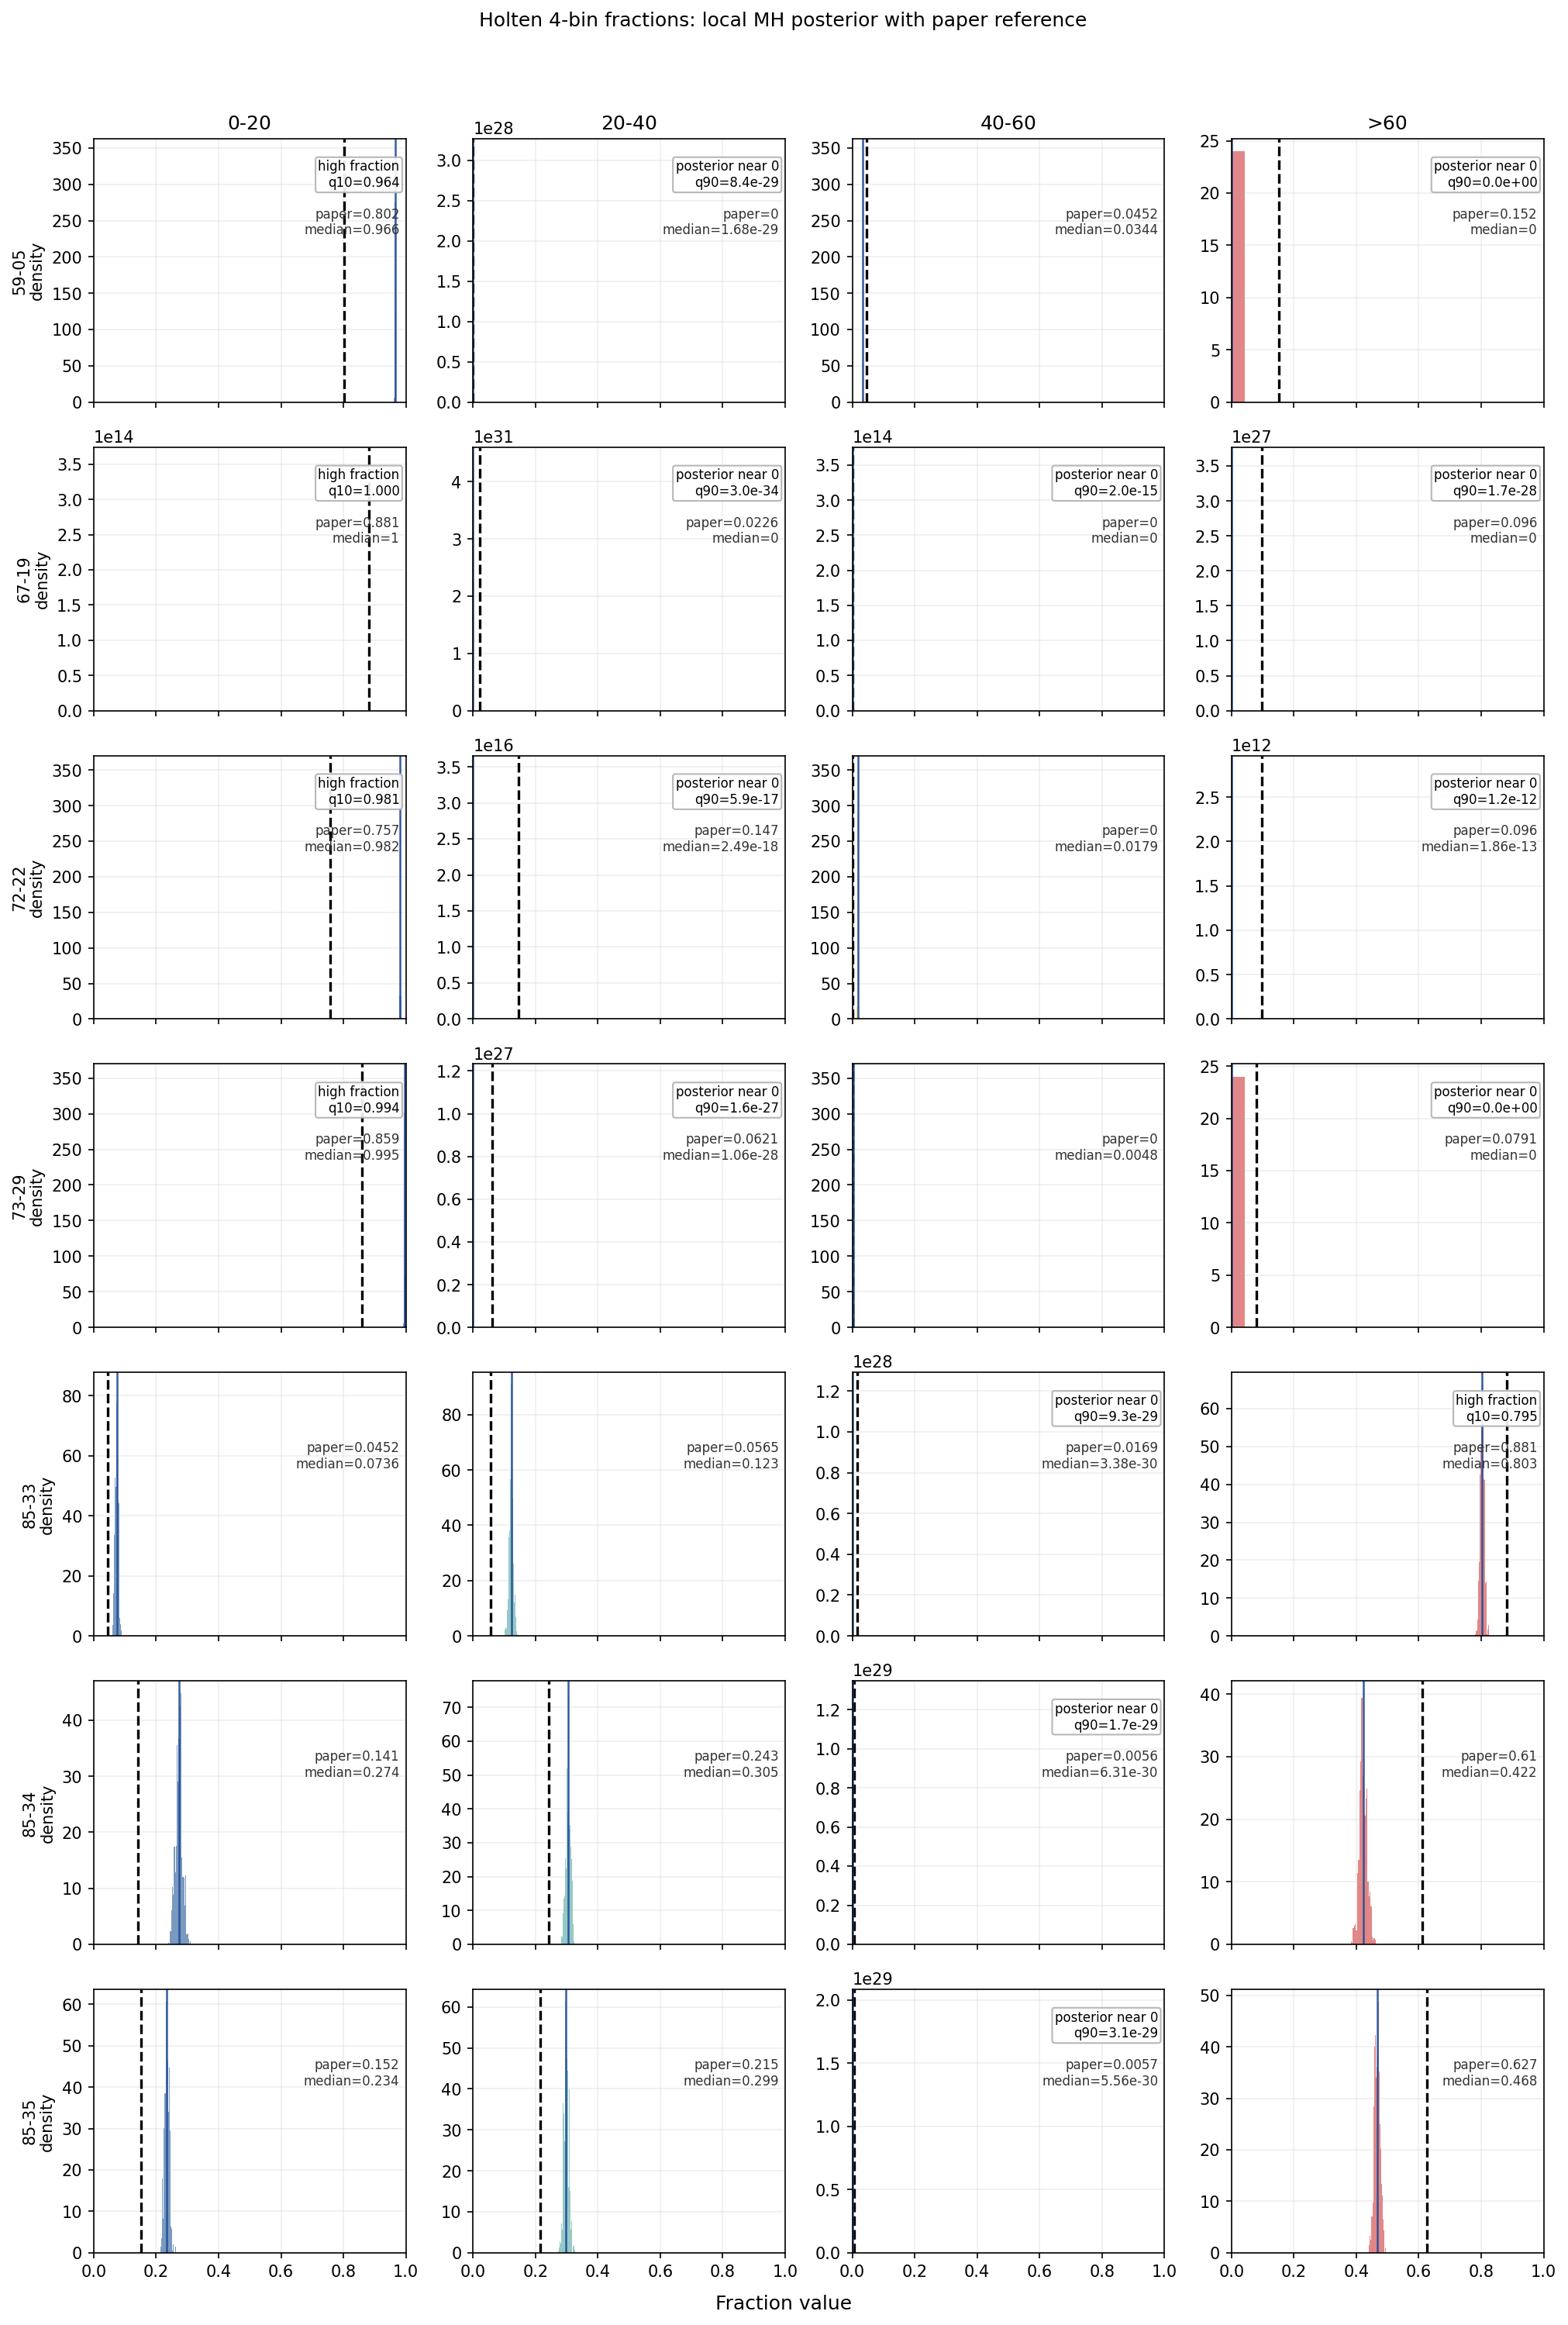

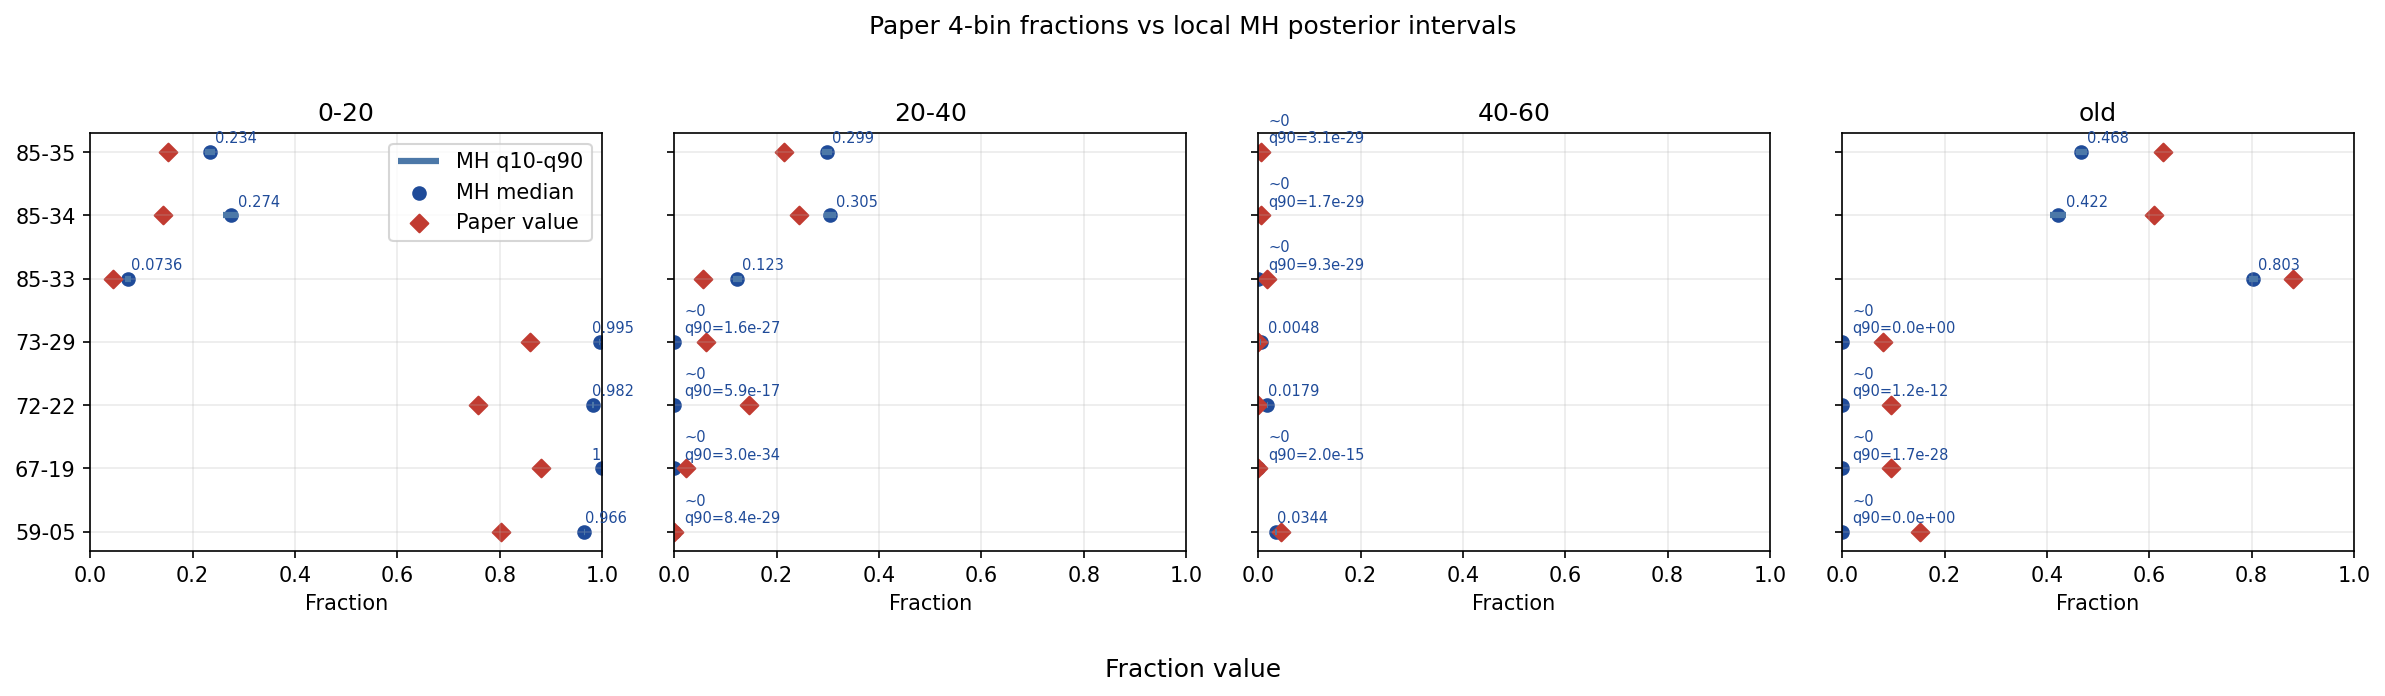

In [15]:
for name in ["holten_4bin_mh_fraction_posteriors.png", "holten_4bin_paper_vs_mh_intervals.png"]:
    display(Image(filename=str(four_bin_dir / name), width=1000))


### Posterior summary

This table gives a more detailed view of the local Metropolis-Hastings posterior, including the acceptance rate and the posterior summaries of each fraction.


In [16]:
mh_posterior[[
    "well_id", "nsamples", "acceptance_rate_mean",
    "f_0_20_median", "f_0_20_q10", "f_0_20_q90",
    "f_20_40_median", "f_20_40_q10", "f_20_40_q90",
    "f_40_60_median", "f_40_60_q10", "f_40_60_q90",
    "f_old_median", "f_old_q10", "f_old_q90",
]].round(4)


,well_id,nsamples,acceptance_rate_mean,f_0_20_median,f_0_20_q10,f_0_20_q90,f_20_40_median,f_20_40_q10,f_20_40_q90,f_40_60_median,f_40_60_q10,f_40_60_q90,f_old_median,f_old_q10,f_old_q90
0,59-05,3200,0.2415,0.9656,0.9640,0.9671,0.0000,0.0000,0.0000,0.0344,0.0329,0.0360,0.0000,0.0000,0.0000
1,67-19,3200,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,72-22,3200,0.4120,0.9821,0.9808,0.9837,0.0000,0.0000,0.0000,0.0179,0.0163,0.0192,0.0000,0.0000,0.0000
3,73-29,3200,0.7738,0.9952,0.9937,0.9966,0.0000,0.0000,0.0000,0.0048,0.0034,0.0063,0.0000,0.0000,0.0000
4,85-33,3200,0.1900,0.0736,0.0671,0.0802,0.1227,0.1149,0.1314,0.0000,0.0000,0.0000,0.8032,0.7945,0.8121
5,85-34,3200,0.1220,0.2740,0.2585,0.2877,0.3051,0.2933,0.3152,0.0000,0.0000,0.0000,0.4216,0.4069,0.4373
6,85-35,3200,0.0990,0.2341,0.2250,0.2437,0.2986,0.2887,0.3083,0.0000,0.0000,0.0000,0.4676,0.4564,0.4793


## 7. Well-by-well synthesis

This last section regroups the prepared data and the local `4-bin` results well by well. For each production well, it shows:
- the multi-tracer panel used in the pre-model reading;
- the prepared tracer observations;
- the conversion log from the source table to the local PyAge-ready dataset;
- the local `3H/3He` and helium context;
- the local `4-bin` tracer fit;
- and the fraction comparison between the paper, the deterministic local fit, and the local Metropolis-Hastings posterior.

### Well `59-05`

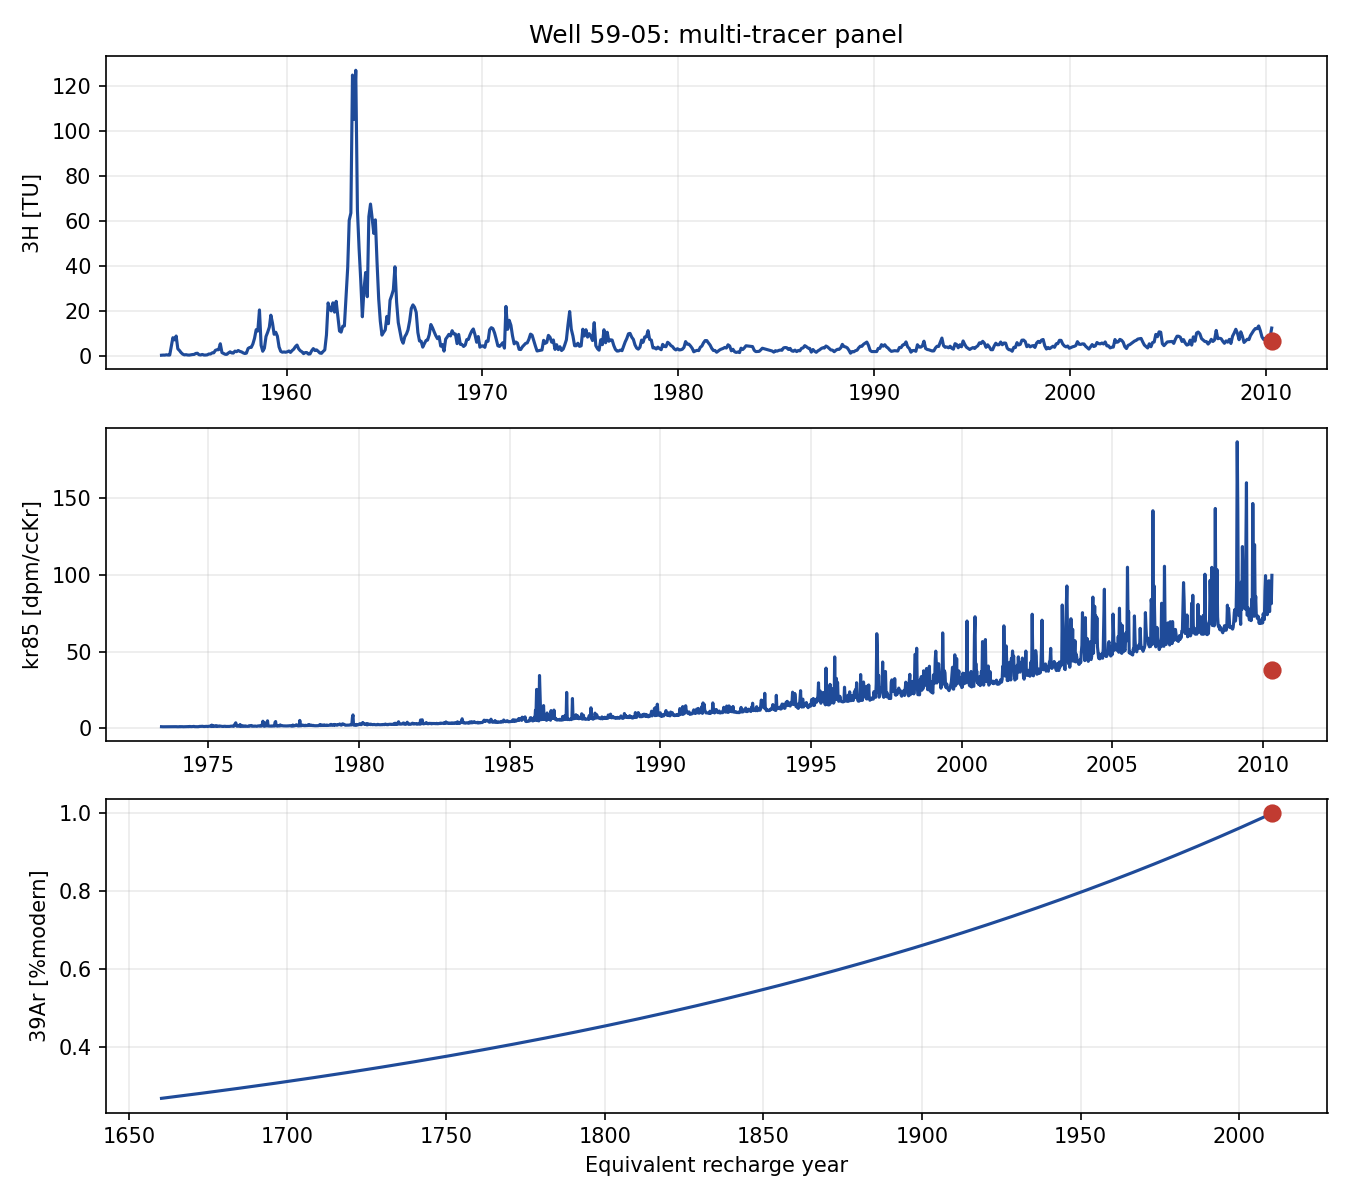

**Prepared tracer observations**

,observed,obs_error,unit,date
element,,,,
3H,6.48,0.14,TU,2010.299
kr85,38.00,1.20,dpm/ccKr,2010.299
39Ar,1.00,0.10,%modern,2010.299


**Conversion log**

,raw_value,raw_unit,converted_value,converted_unit,conversion_rule
element,,,,,
3H,6.48,TU,6.48,TU,none
kr85,38.00,dpm/ccKr,38.00,dpm/ccKr,none
39Ar,100.00,pMC,1.00,%modern,pMC / 100


**3H/3He and helium context**

...

,paper,local_fit,mh_q10,mh_median,mh_q90
0-20,0.8023,0.9655,0.9640,0.9656,0.9671
20-40,0.0000,0.0000,0.0000,0.0000,0.0000
40-60,0.0452,0.0345,0.0329,0.0344,0.0360
>60,0.1525,0.0000,0.0000,0.0000,0.0000


**Local fit metrics**

,59-05
chi2_local_4bin,34.276315
rmse_local_4bin,0.735127
mean_age_local_4bin,11.379608
mh_acceptance_rate,0.2415
optimization_success,True


---

### Well `67-19`

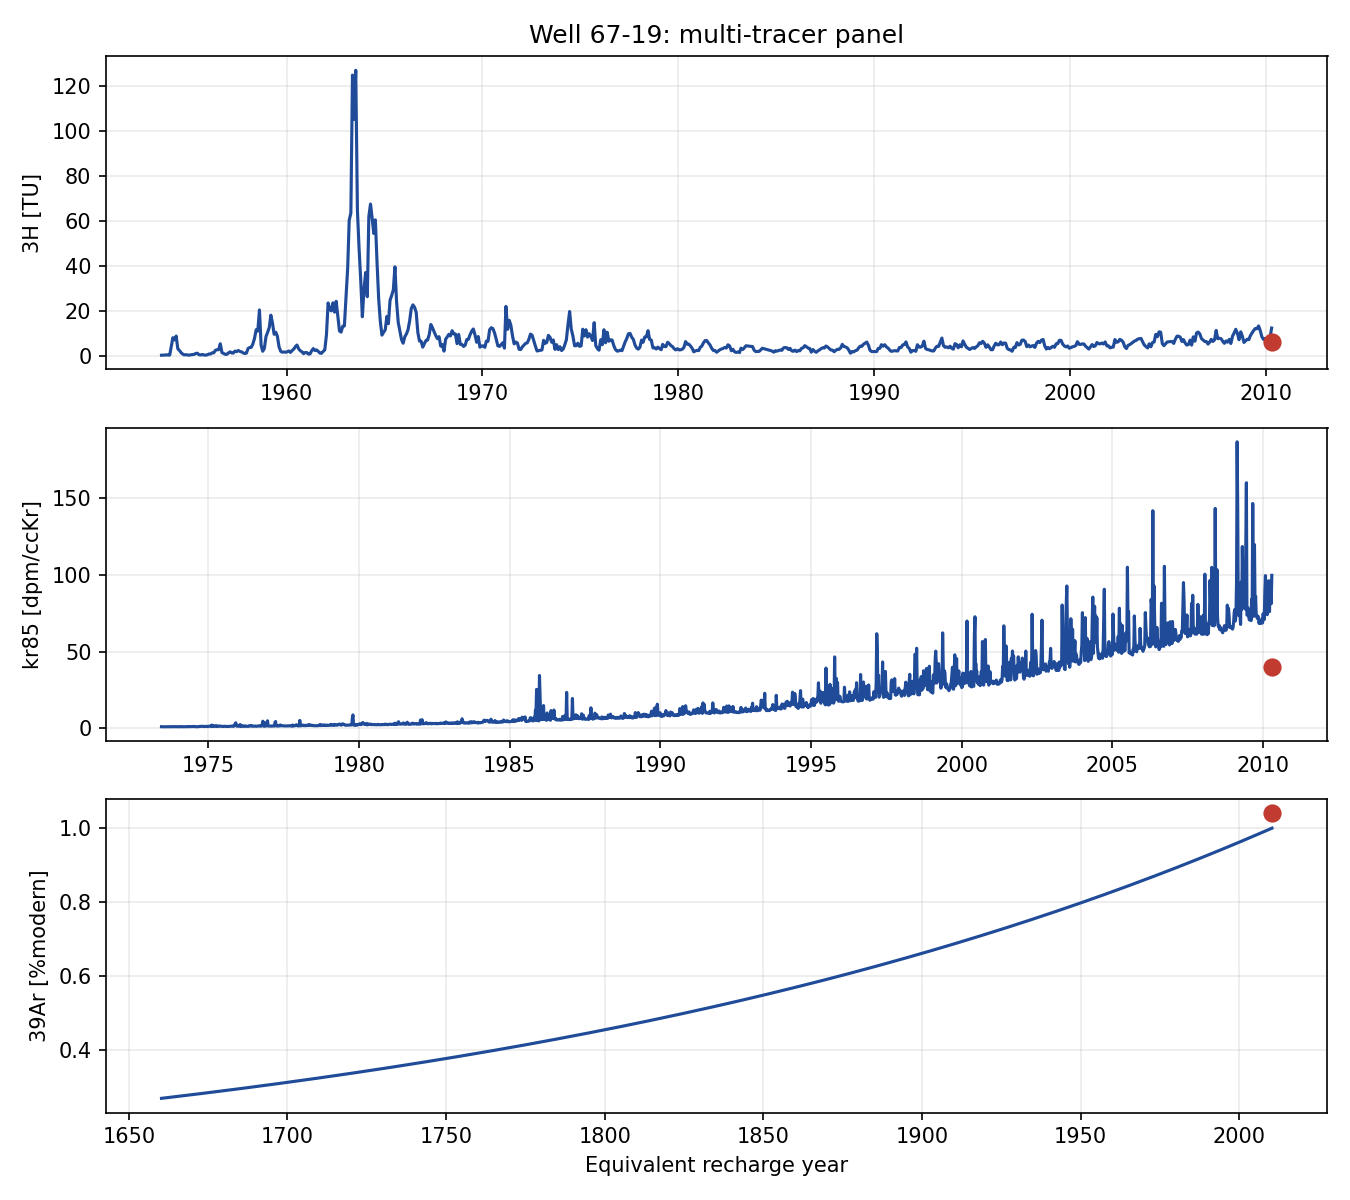

**Prepared tracer observations**

,observed,obs_error,unit,date
element,,,,
3H,6.09,0.15,TU,2010.301
kr85,39.70,1.50,dpm/ccKr,2010.301
39Ar,1.04,0.08,%modern,2010.301


**Conversion log**

,raw_value,raw_unit,converted_value,converted_unit,conversion_rule
element,,,,,
3H,6.09,TU,6.09,TU,none
kr85,39.70,dpm/ccKr,39.70,dpm/ccKr,none
39Ar,104.00,pMC,1.04,%modern,pMC / 100


**3H/3He and helium context**

...

,paper,local_fit,mh_q10,mh_median,mh_q90
0-20,0.8814,1.0,1.0,1.0,1.0
20-40,0.0226,0.0,0.0,0.0,0.0
40-60,0.0000,0.0,0.0,0.0,0.0
>60,0.0960,0.0,0.0,0.0,0.0


**Local fit metrics**

,67-19
chi2_local_4bin,16.515194
rmse_local_4bin,0.859693
mean_age_local_4bin,10.0
mh_acceptance_rate,1.0
optimization_success,True


---

### Well `72-22`

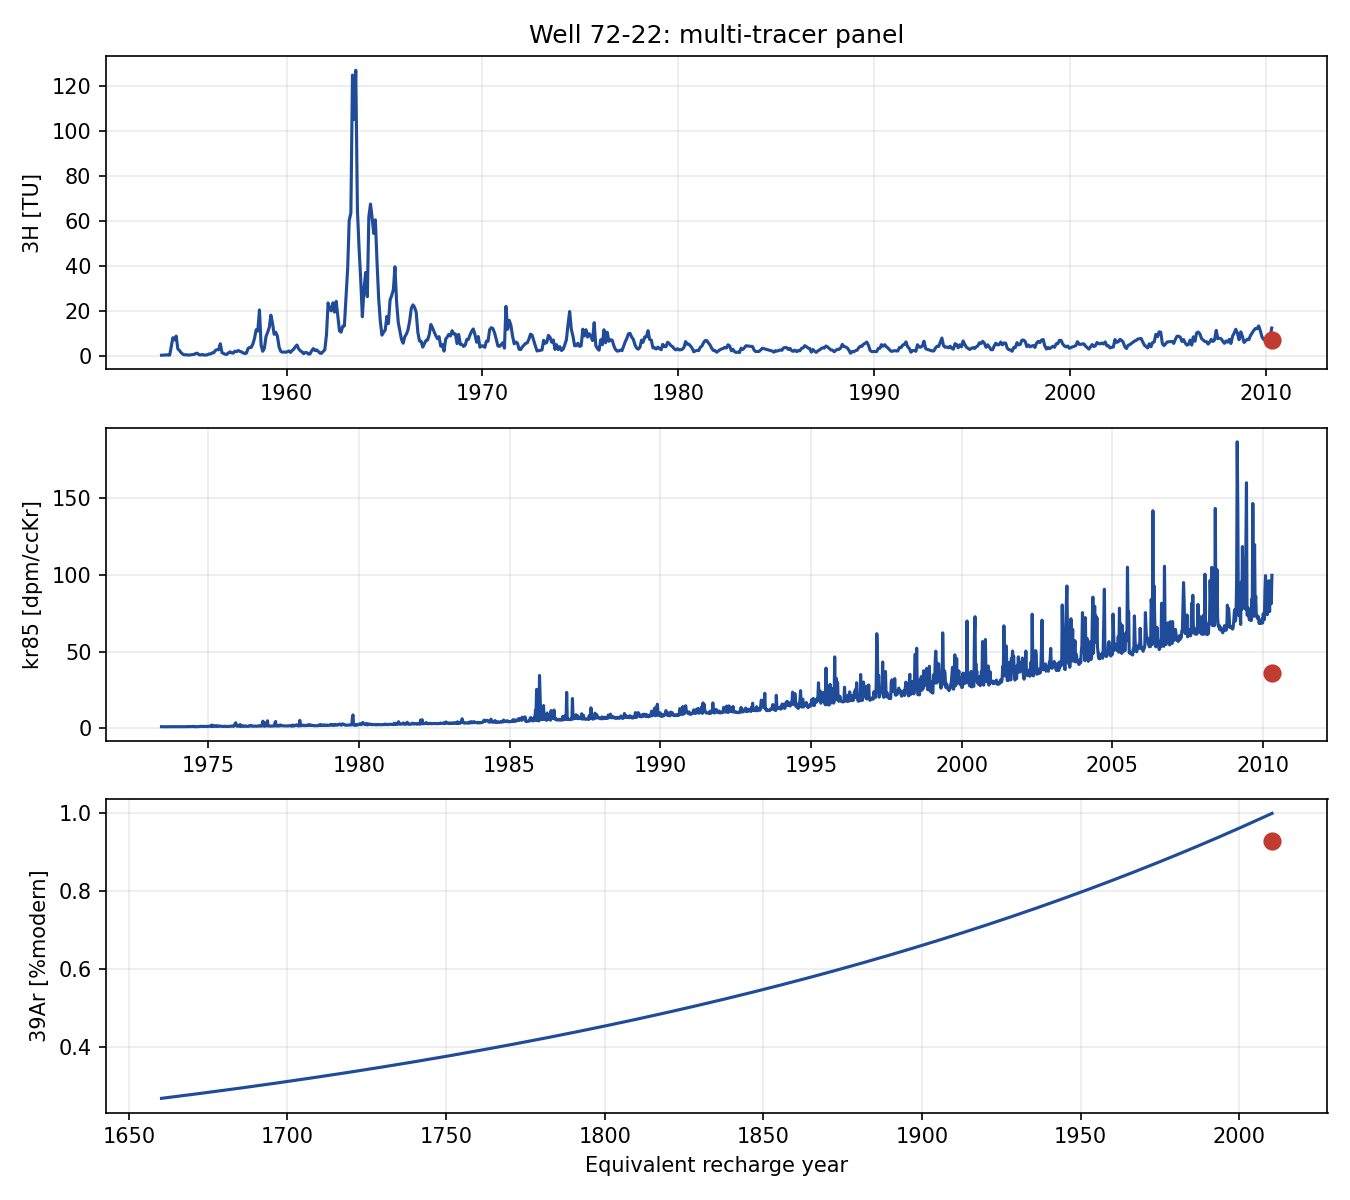

**Prepared tracer observations**

,observed,obs_error,unit,date
element,,,,
3H,6.75,0.16,TU,2010.299
kr85,35.90,1.30,dpm/ccKr,2010.299
39Ar,0.93,0.06,%modern,2010.299


**Conversion log**

,raw_value,raw_unit,converted_value,converted_unit,conversion_rule
element,,,,,
3H,6.75,TU,6.75,TU,none
kr85,35.90,dpm/ccKr,35.90,dpm/ccKr,none
39Ar,93.00,pMC,0.93,%modern,pMC / 100


**3H/3He and helium context**

...

,paper,local_fit,mh_q10,mh_median,mh_q90
0-20,0.7571,0.9821,0.9808,0.9821,0.9837
20-40,0.1469,0.0000,0.0000,0.0000,0.0000
40-60,0.0000,0.0179,0.0163,0.0179,0.0192
>60,0.0960,0.0000,0.0000,0.0000,0.0000


**Local fit metrics**

,72-22
chi2_local_4bin,53.217963
rmse_local_4bin,0.949814
mean_age_local_4bin,10.714697
mh_acceptance_rate,0.412
optimization_success,True


---

### Well `73-29`

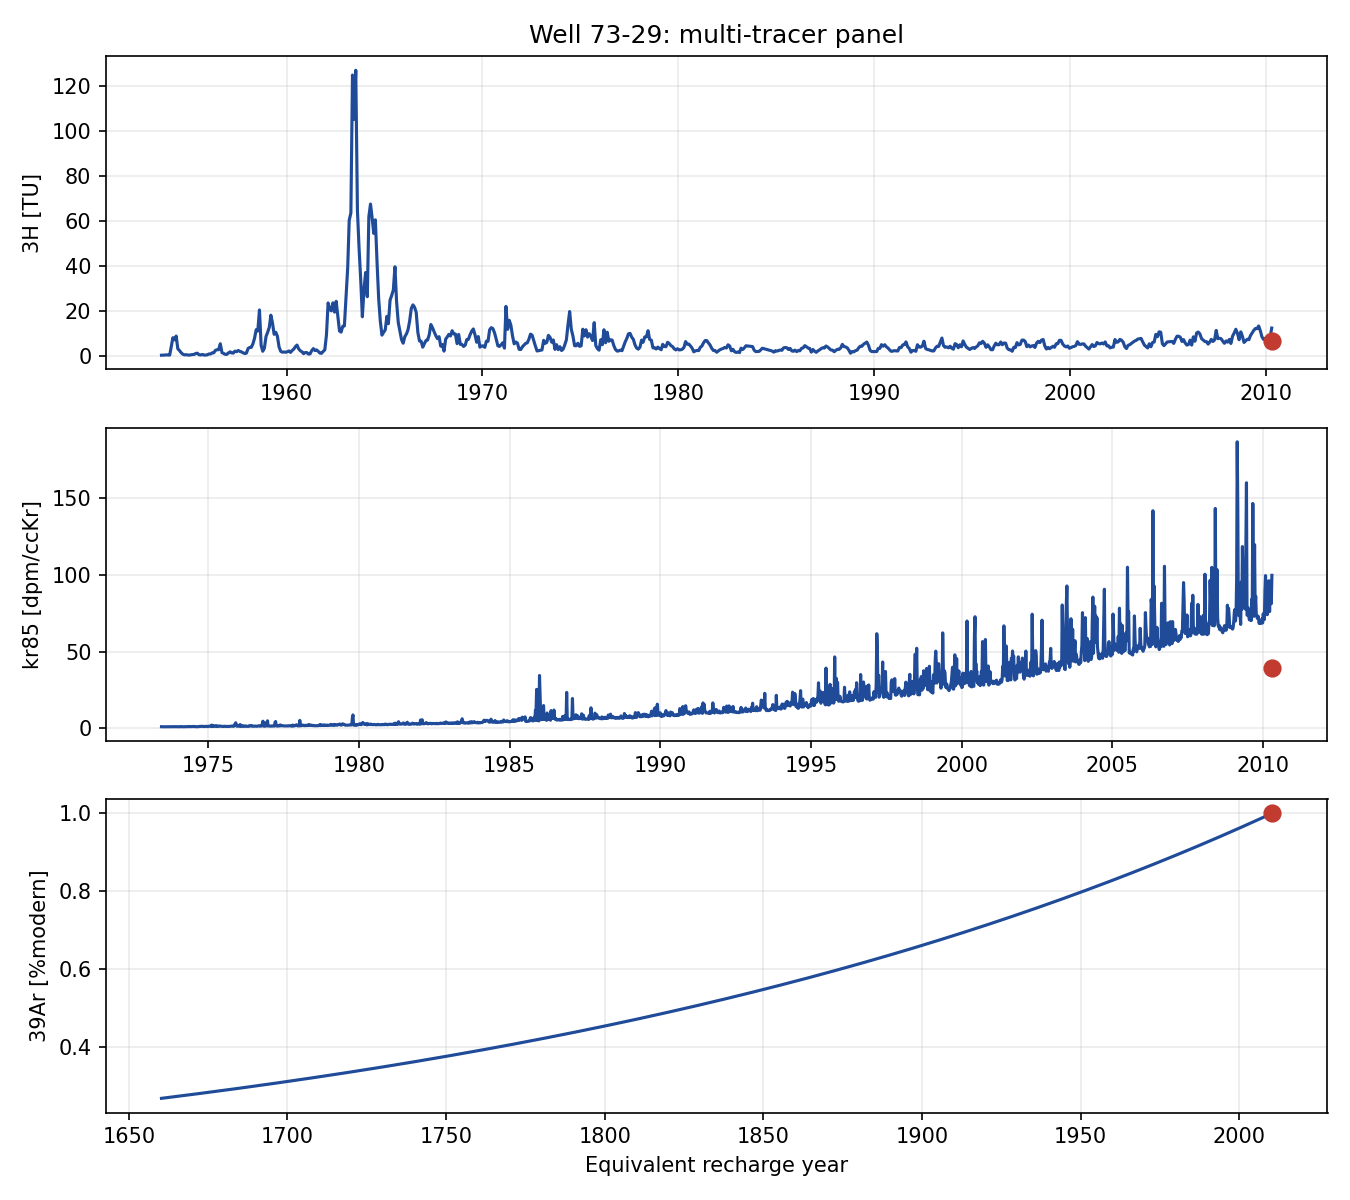

**Prepared tracer observations**

,observed,obs_error,unit,date
element,,,,
3H,6.38,0.16,TU,2010.299
kr85,39.40,1.60,dpm/ccKr,2010.299
39Ar,1.00,0.10,%modern,2010.299


**Conversion log**

,raw_value,raw_unit,converted_value,converted_unit,conversion_rule
element,,,,,
3H,6.38,TU,6.38,TU,none
kr85,39.40,dpm/ccKr,39.40,dpm/ccKr,none
39Ar,100.00,pMC,1.00,%modern,pMC / 100


**3H/3He and helium context**

...

,paper,local_fit,mh_q10,mh_median,mh_q90
0-20,0.8588,0.9948,0.9937,0.9952,0.9966
20-40,0.0621,0.0000,0.0000,0.0000,0.0000
40-60,0.0000,0.0052,0.0034,0.0048,0.0063
>60,0.0791,0.0000,0.0000,0.0000,0.0000


**Local fit metrics**

,73-29
chi2_local_4bin,28.276743
rmse_local_4bin,0.86438
mean_age_local_4bin,10.208564
mh_acceptance_rate,0.77375
optimization_success,True


---

### Well `85-33`

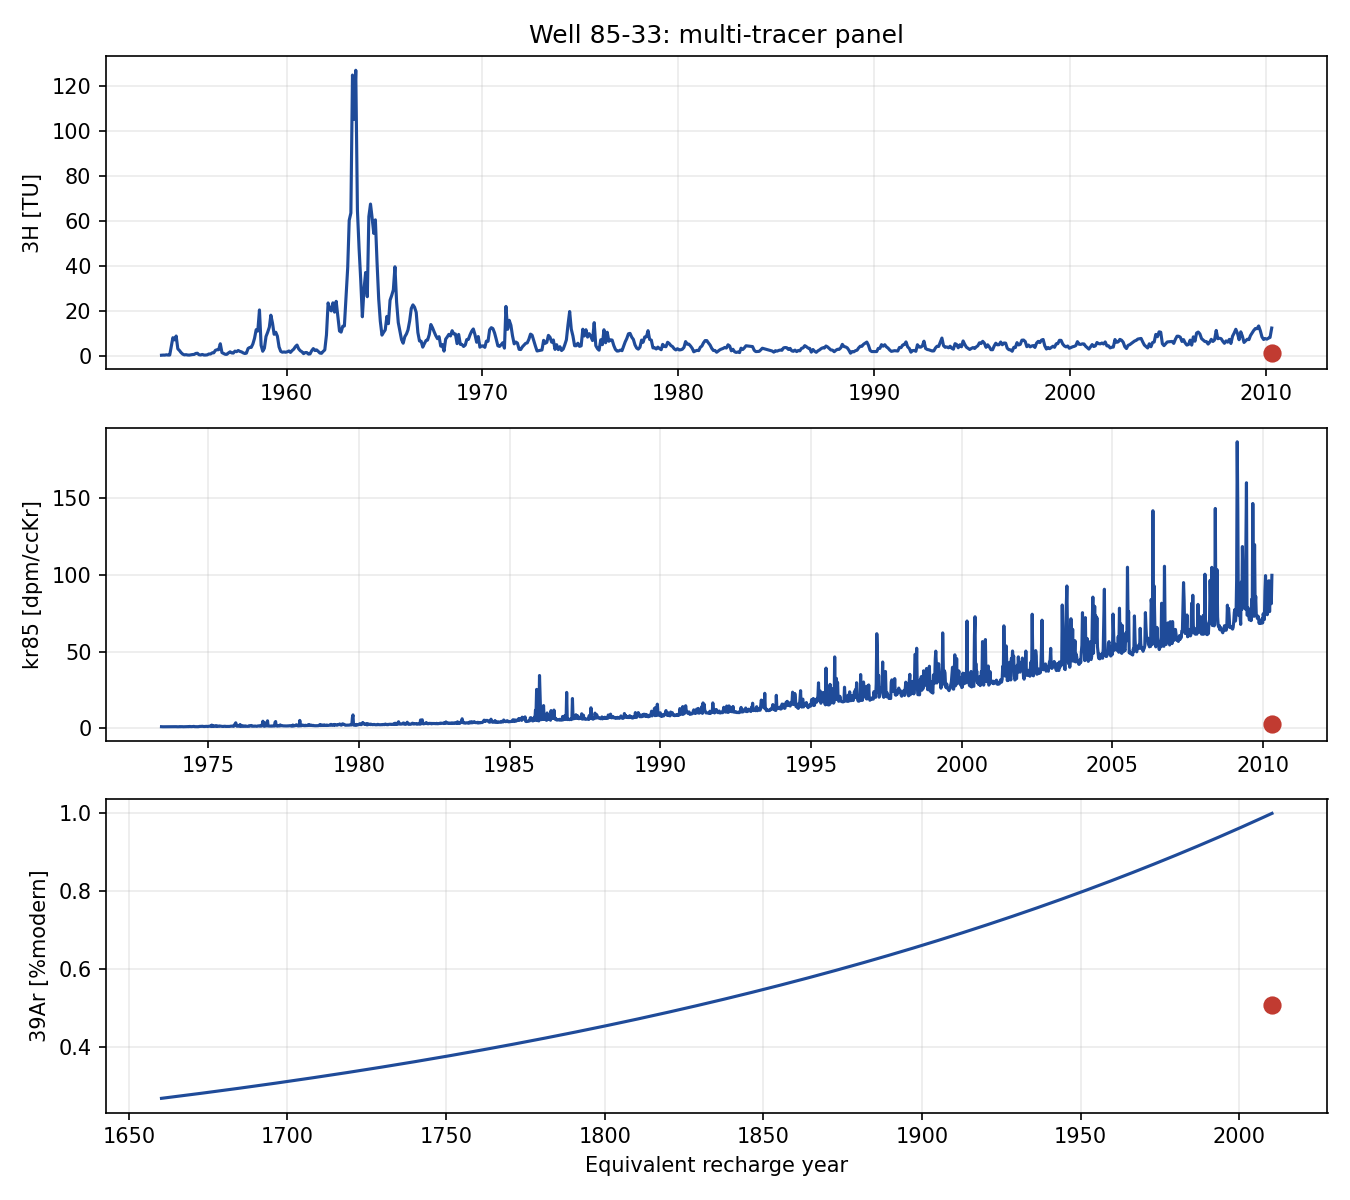

**Prepared tracer observations**

,observed,obs_error,unit,date
element,,,,
3H,1.23,0.05,TU,2010.299
kr85,2.70,0.20,dpm/ccKr,2010.299
39Ar,0.51,0.08,%modern,2010.299


**Conversion log**

,raw_value,raw_unit,converted_value,converted_unit,conversion_rule
element,,,,,
3H,1.23,TU,1.23,TU,none
kr85,2.70,dpm/ccKr,2.70,dpm/ccKr,none
39Ar,51.00,pMC,0.51,%modern,pMC / 100


**3H/3He and helium context**

...

,paper,local_fit,mh_q10,mh_median,mh_q90
0-20,0.0452,0.0740,0.0671,0.0736,0.0802
20-40,0.0565,0.1233,0.1149,0.1227,0.1314
40-60,0.0169,0.0000,0.0000,0.0000,0.0000
>60,0.8814,0.8028,0.7945,0.8032,0.8121


**Local fit metrics**

,85-33
chi2_local_4bin,38.431989
rmse_local_4bin,0.837674
mean_age_local_4bin,253.291948
mh_acceptance_rate,0.19
optimization_success,True


---

### Well `85-34`

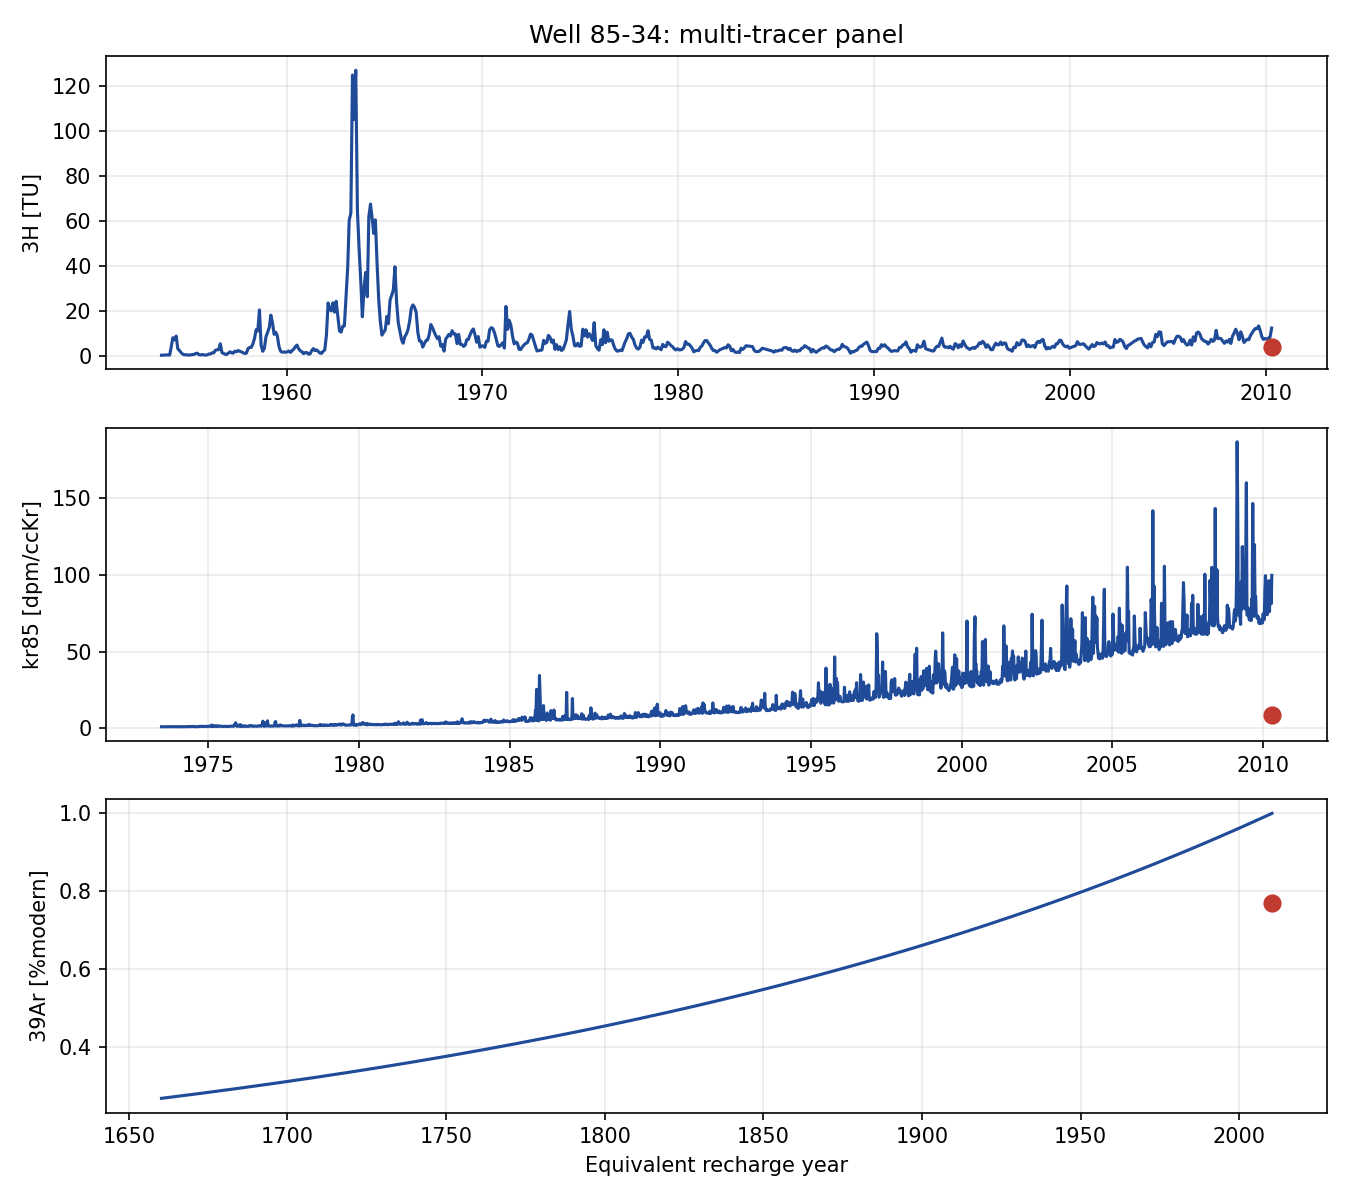

**Prepared tracer observations**

,observed,obs_error,unit,date
element,,,,
3H,3.98,0.11,TU,2010.301
kr85,8.40,0.50,dpm/ccKr,2010.301
39Ar,0.77,0.07,%modern,2010.301


**Conversion log**

,raw_value,raw_unit,converted_value,converted_unit,conversion_rule
element,,,,,
3H,3.98,TU,3.98,TU,none
kr85,8.40,dpm/ccKr,8.40,dpm/ccKr,none
39Ar,77.00,pMC,0.77,%modern,pMC / 100


**3H/3He and helium context**

...

,paper,local_fit,mh_q10,mh_median,mh_q90
0-20,0.1412,0.2742,0.2585,0.2740,0.2877
20-40,0.2430,0.3047,0.2933,0.3051,0.3152
40-60,0.0056,0.0000,0.0000,0.0000,0.0000
>60,0.6102,0.4212,0.4069,0.4216,0.4373


**Local fit metrics**

,85-34
chi2_local_4bin,136.391721
rmse_local_4bin,1.761427
mean_age_local_4bin,142.43938
mh_acceptance_rate,0.122
optimization_success,True


---

### Well `85-35`

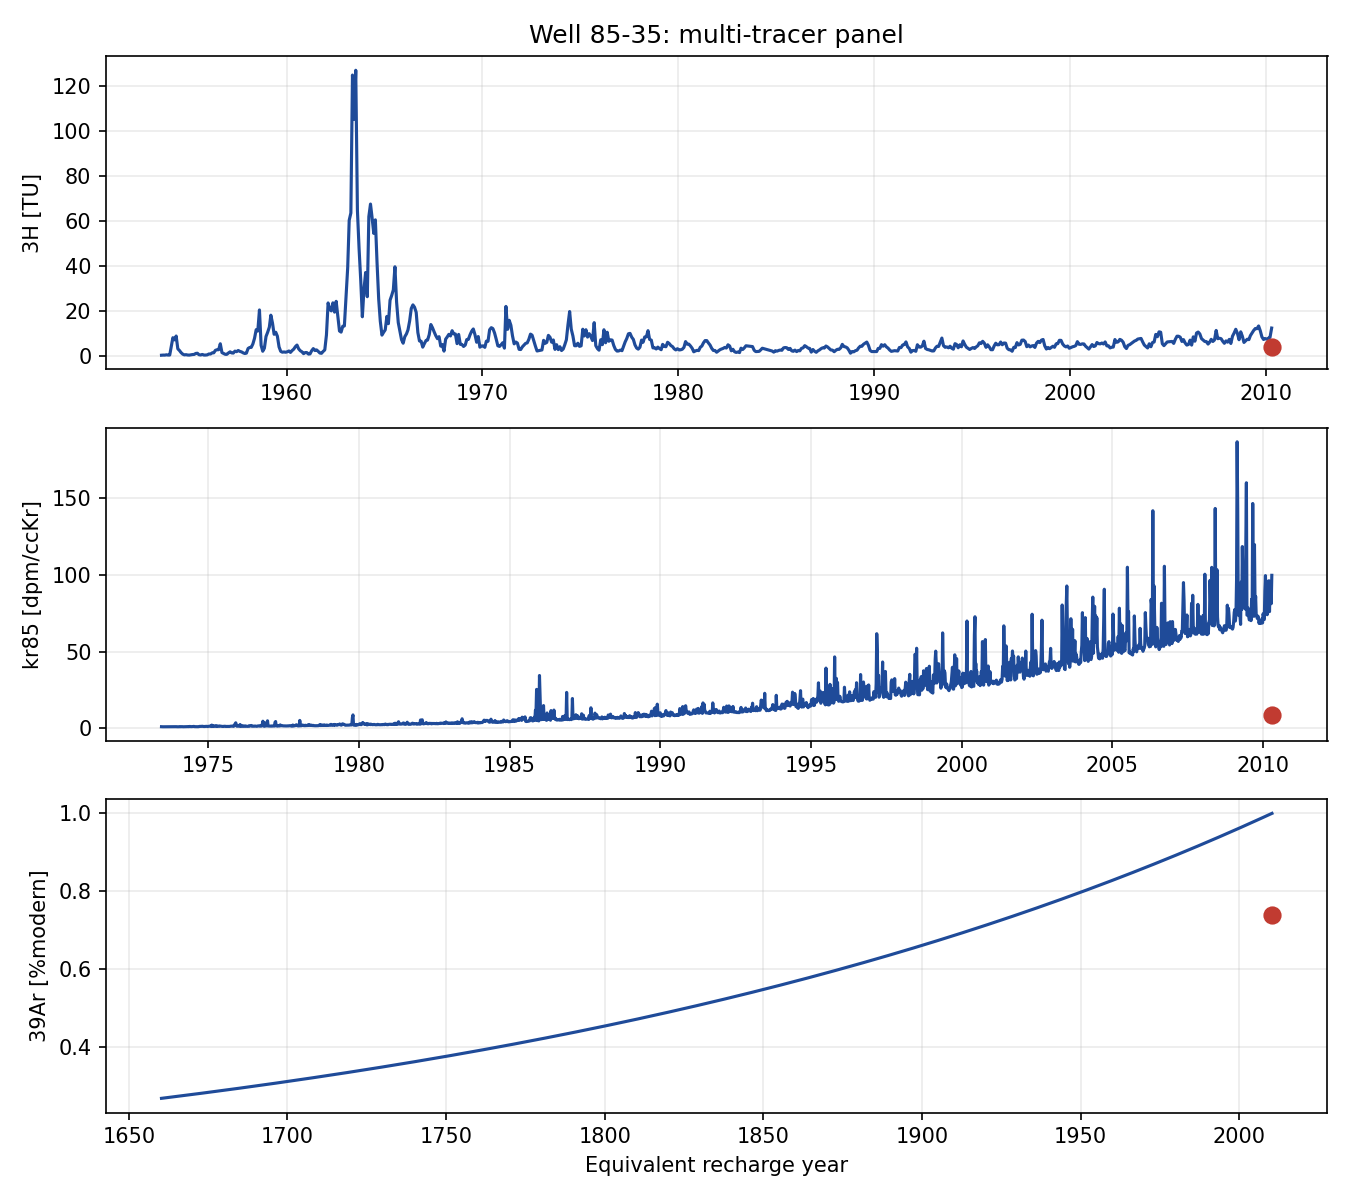

**Prepared tracer observations**

,observed,obs_error,unit,date
element,,,,
3H,3.82,0.11,TU,2010.301
kr85,8.70,0.30,dpm/ccKr,2010.301
39Ar,0.74,0.06,%modern,2010.301


**Conversion log**

,raw_value,raw_unit,converted_value,converted_unit,conversion_rule
element,,,,,
3H,3.82,TU,3.82,TU,none
kr85,8.70,dpm/ccKr,8.70,dpm/ccKr,none
39Ar,74.00,pMC,0.74,%modern,pMC / 100


**3H/3He and helium context**

...

**4-bin fractions: paper vs local fit vs MH**

,paper,local_fit,mh_q10,mh_median,mh_q90
0-20,0.1525,0.2344,0.2250,0.2341,0.2437
20-40,0.2147,0.2977,0.2887,0.2986,0.3083
40-60,0.0057,0.0000,0.0000,0.0000,0.0000
>60,0.6271,0.4679,0.4564,0.4676,0.4793


**Local fit metrics**

,85-35
chi2_local_4bin,133.479736
rmse_local_4bin,1.151853
mean_age_local_4bin,156.318646
mh_acceptance_rate,0.099
optimization_success,True


---

In [17]:
import pandas as pd
from IPython.display import Markdown

if not hasattr(prepared, "helium_diagnostics"):
    import importlib
    import examples.natural.holten.holten_prepare as holten_prepare_module

    holten_prepare_module = importlib.reload(holten_prepare_module)
    prepare_holten_inputs = holten_prepare_module.prepare_holten_inputs
    prepared = prepare_holten_inputs()

pre_model_dir = ctx.paths.benchmark_dir / "pre_model"
four_bin_dir = ctx.paths.benchmark_dir / "four_bin"

if "local_4bin_summary" not in globals() or "local_4bin_fit" not in globals():
    local_4bin_endmembers, local_4bin_summary, local_4bin_fit, four_bin_paths = run_local_4bin(prepared, four_bin_dir)

if "paper_4bin" not in globals() or "mh_posterior" not in globals() or "paper_vs_mh" not in globals():
    paper_4bin, mh_posterior, paper_vs_mh, mh_paths = run_local_4bin_mh(prepared, four_bin_dir)

prepared_order = ["3H", "kr85", "39Ar"]
fit_order = ["3H", "3He_trit", "kr85", "39Ar"]
fraction_rows = ["0-20", "20-40", "40-60", ">60"]

for well_id in prepared.context.selected_wells:
    display(Markdown(f"### Well `{well_id}`"))

    panel_path = pre_model_dir / f"well_{well_id}_multi_tracer_panel.png"
    if panel_path.exists():
        display(Image(filename=str(panel_path), width=820))

    observed = prepared.observed_by_well[well_id].copy()
    observed["element"] = pd.Categorical(observed["element"], categories=prepared_order, ordered=True)
    observed = observed.sort_values(["element", "date"]).reset_index(drop=True)
    observed = observed.rename(columns={"concentration": "observed", "error": "obs_error"}).set_index("element")
    display(Markdown("**Prepared tracer observations**"))
    display(observed.round(3))

    prep = prepared.preparation_log.loc[prepared.preparation_log["well_id"] == well_id, [
        "element", "raw_value", "raw_unit", "converted_value", "converted_unit", "conversion_rule"
    ]].copy()
    prep["element"] = pd.Categorical(prep["element"], categories=prepared_order, ordered=True)
    prep = prep.sort_values("element").set_index("element")
    display(Markdown("**Conversion log**"))
    display(prep.round(3))

    helium = prepared.helium_diagnostics.loc[prepared.helium_diagnostics["well_id"] == well_id, [
        "3H_TU", "3H_err", "3He_trit_TU", "3He_err_raw", "3He_err", "3He_err_source",
        "tritium_initial_TU", "tritium_initial_err", "H3_He_age_yr", "H3_He_age_ratio_yr",
        "H3_He_age_ratio_delta_yr", "He4_terr", "He4_total", "DeltaNe_pct", "DeltaNe_screening"
    ]].copy()
    display(Markdown("**3H/3He and helium context**"))
    if not helium.empty:
        display(helium.round(3).T.rename(columns={helium.index[0]: well_id}))
    else:
        display(pd.DataFrame(index=[well_id]))

    fit = local_4bin_fit.loc[local_4bin_fit["well_id"] == well_id, [
        "tracer", "observed", "error", "modeled", "residual", "weighted_residual"
    ]].copy()
    fit["tracer"] = pd.Categorical(fit["tracer"], categories=fit_order, ordered=True)
    fit = fit.sort_values("tracer").set_index("tracer")
    display(Markdown("**Local 4-bin tracer fit**"))
    display(fit.round(4))

    local_row = local_4bin_summary.loc[local_4bin_summary["well_id"] == well_id].iloc[0]
    paper_row = paper_4bin.loc[paper_4bin["well_id"] == well_id].iloc[0]
    mh_row = mh_posterior.loc[mh_posterior["well_id"] == well_id].iloc[0]

    fraction_table = pd.DataFrame({
        "paper": [paper_row["f_0_20"], paper_row["f_20_40"], paper_row["f_40_60"], paper_row["f_old"]],
        "local_fit": [local_row["f_0_20"], local_row["f_20_40"], local_row["f_40_60"], local_row["f_old"]],
        "mh_q10": [mh_row["f_0_20_q10"], mh_row["f_20_40_q10"], mh_row["f_40_60_q10"], mh_row["f_old_q10"]],
        "mh_median": [mh_row["f_0_20_median"], mh_row["f_20_40_median"], mh_row["f_40_60_median"], mh_row["f_old_median"]],
        "mh_q90": [mh_row["f_0_20_q90"], mh_row["f_20_40_q90"], mh_row["f_40_60_q90"], mh_row["f_old_q90"]],
    }, index=fraction_rows)
    display(Markdown("**4-bin fractions: paper vs local fit vs MH**"))
    display(fraction_table.round(4))

    metrics = pd.DataFrame({
        well_id: {
            "chi2_local_4bin": local_row["chi2_local_4bin"],
            "rmse_local_4bin": local_row["rmse_local_4bin"],
            "mean_age_local_4bin": local_row["mean_age_local_4bin"],
            "mh_acceptance_rate": mh_row["acceptance_rate_mean"],
            "optimization_success": local_row["optimization_success"],
        }
    })
    display(Markdown("**Local fit metrics**"))
    display(metrics.round(4))

    display(Markdown("---"))
